# <a id="top"></a> Modeling Exoplanets and Substellar Companions at Optical Wavelengths 

In this PICASO tutorial, you will learn the basic PICASO workflow for computing **thermal emission** and **reflected light** spectra. Along the way, you will also build your intuition for what physical information they encode. We'll focus in particular on Roman-CGI wavelengths. Actual data-model comparison is covered in the next tutorial notebook and supplementary quickstart notebooks.

**Using PICASO to Compute Spectra**

[0) Python imports and setting directory paths](#0Python)

[1) Connect to the desired opacity database](#1Connect)

[2) Initiate a blank instance of the PICASO `inputs` class](#2Initiate)

[3) Set stellar and planetary parameters](#3Set) 

[4) Define the atmosphere profile](#4Define) 

[5) Compute spectra](#5Compute)

**Exploration and Intuition Building**

[6) Sonora-Bobcat and Batalha+2018 model grids](#6Grids)

[7) Clouds](#7Clouds) 

[8) Interpreting spectral features](#8Interpreting)

[9) Non-zero orbital phase](#9Non-zero)

[10) Culminating parameter space study](#10Culminating) 

--------------------------
## <a id="0Python"></a>0. Python imports and setting directory paths

Every time you run PICASO it expects environment variables named `picaso_refdata` and `PYSYN_CDBS` to exist. Let's set these up with the `os` package right before importing picaso. 

When working with in Google Co Lab you also need to first mount the contents of your google drive where we downloaded the reference data earlier. Pick one of the following two cells to run based on whether you are working in **Google Co Lab** or working in a **local installation**.

In [4]:
# THIS CELL FOR LOCAL INSTALL ONLY

import os
# ── set your own paths here ──────────────────────────────────────
PICASO_REFDATA = '/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference'
PYSYN_CDBS = '/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/stellar_grids'
# ─────────────────────────────────────────────────────────────────
os.environ['picaso_refdata'] = PICASO_REFDATA
os.environ['PYSYN_CDBS'] = PYSYN_CDBS

In [ ]:
# THIS CELL FOR GOOGLE CO LAB ONLY

from google.colab import drive
drive.mount("/content/drive")
drive_dir = "/content/drive/MyDrive/"

import os
# if you stored things in drive with names from tutorial A, there 
# should be no need to edit this
reference_prefix_dir = 'RomanSchoolPICASO'
reference_prefix_dir = os.path.join(drive_dir, reference_prefix_dir)
os.chdir(reference_prefix_dir)

PICASO_REFDATA = reference_prefix_dir+'/picaso-reference-romanschool'
PYSYN_CDBS = reference_prefix_dir+'/stellar_grids'
os.environ['picaso_refdata'] = PICASO_REFDATA
os.environ['PYSYN_CDBS'] = PYSYN_CDBS

!pip install picaso

### Frome here on out, everything should be the same for either a local install or Google Co Lab

In [5]:
# THIS CELL FOR EVERYONE

#quick check that the above lines worked, see whether printed paths are where you expect them to be
refdata = os.getenv("picaso_refdata")
print(refdata)
stellardata = os.getenv("PYSYN_CDBS")
print(stellardata)

/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference
/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/stellar_grids


In [6]:
# THIS CELL FOR EVERYONE

#picaso will throw some warnings that we want to ignore
import warnings
warnings.filterwarnings('ignore')

#import picaso
from picaso import justdoit as jdi   #this module contains drivers for the actual picaso calucations
from picaso import justplotit as jpi #this module contains useful plotting routines
jpi.output_notebook()


#for this tutorial we'll also import the following
import numpy as np
import sys
sys.path.insert(0, '.') # this will help make sure we find roman_tutorial_utils
import roman_tutorial_utils as rtu
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

Loading BokehJS ...

[notebook top](#top) | [section top](#0Python)

--------------------------
## <a id="1Connect"></a>1. Connect to the desired opacity database

Every time you want to compute a spectrum, you need to pass PICASO a `RetrieveOpacities` object that stores information about what opacities are available and where to find them. The most convenient way to create one is via the `opannection` helper function. 

Under the hood, `RetrieveOpacities` objects leverage SQL to efficiently store and access opacities. Working with opacity absorption cross-sections can get unwieldy since they typically include  data for n_absorbers x n_wavelengths x n_pressures x n_temperatures. PICASO nicely tracks this for you, but note that computation time will increase the more species and the more wavelength points you include.

By default `opannection` will go look through whatever directory you have set as `picaso_refdata` for files with `opacit` in the name and the `.db` extension, and it will use the full wavelength range within that database. To prevent misunderstandings, I recommend always instantiating it with two kwargs: (1) `filename_db` a path to the opacity database and (2) `wave_range` the wavelength range that you want to use. 

In [7]:
opacity_db = os.path.join(os.getenv('picaso_refdata'),'opacities', 'opacities_roman_school_0.4_7_R10000.db')
print(opacity_db)
opa = jdi.opannection(filename_db=opacity_db, #pass in the path to the opacity database we want to use
                      wave_range=[0.4,1.0])   #lower and upper bounds for wavelength range in microns

/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/opacities/opacities_roman_school_0.4_7_R10000.db


Let's take a quick look at the result... 

In [8]:
print(opa.molecules) #here is a list of the molecules included in the opacity database
print(1e4/opa.wno)   #here is how to access the wavelengths opacity data is on -- note the .wno gives wavenumbers in 1/cm
print(opa.avail_continuum) #here is a list of the non-rayleigh scattering continuum opacity sources

['CH4' 'CO' 'CO2' 'CrH' 'FeH' 'H2O' 'H2S' 'HCN' 'K' 'MgH' 'NH3' 'Na' 'PH3'
 'SiO' 'TiO' 'VO']
[0.99991027 0.99981029 0.99971031 ... 0.40008041 0.4000404  0.4000004 ]
['H-bf', 'H-ff', 'H2-', 'H2H2', 'H2He']


Note that this did not actually load any opacity data into memory yet, it is just connecting us to the right places for later. 

[notebook top](#top) | [section top](#1Connect)

--------------------------
## <a id="2Initiate"></a>2. Initiate a blank instance of the PICASO `inputs` class

`inputs` is the core driver object for 1d PICASO calculations. It can be used to compute many different types of spectra and climate models. We'll start with an empty instance and add the information needed to compute a combined reflected-light and thermal emission spectrum step-by-step.

In [9]:
model_inputs = jdi.inputs() 

[notebook top](#top) | [section top](#2Initiate)

--------------------------
## <a id="3Set"></a>3. Set stellar and planetary parameters

PICASO always needs us to set the planet's **surface gravity**, regardless of the type of calculation.

For our calculations of both thermal and reflected light, we also need to set the following:
* $F_{star}$ -- stellar spectrum, PICASO pulls this from a spectral library based on nearest effective temperature, metallicity, and surface gravity, and we also pass a stellar radius
* $d_{sep}$ -- planet-star separation, for a circular orbit this would be the same as the semi-major axis
* $\alpha$ -- orbital phase angle (the angle between the star, planet, and observer, whose vertex lies at the planet)
* $R_{planet}$ -- planet radius

For reflected light, PICASO will calculate the albedo spectrum $a(\lambda, \alpha)$, see https://natashabatalha.github.io/picaso_dev for the detailed math. The albedo spectrum combines with the other parameters to get $F_{planet}$ as follows:

$F_{planet}(\lambda) = F_{star}(\lambda)~\times~\big(\frac{R_{planet}}{d_{sep}}\big)^2 ~\times~ a(\lambda, \alpha)  $

Note that the contrast ratio $F_{planet}/F_{star}$ for reflected-light is actually independent of stellar flux. That is not the case for the contrast ratio $F_{planet}/F_{star}$ for thermal emission calculations. For thermal emission, the planet light is originating from the planet, not coming from the star and bouncing off, so the planet signal is uncorrelated from stellar signal. This distinction is important to keep in mind when considering targets' suitability for Roman-CGI. 

In [10]:
#define planet radius and mass, which together determine a unique surface gravity
model_inputs.gravity(radius=1, radius_unit=jdi.u.Unit('R_jup'), 
                     mass=1, mass_unit=jdi.u.Unit('M_jup'))

#define star and orbital separation
model_inputs.star(opa,  # our the RetrieveOpacities() object
                  5000, # Stellar Teff
                  0,    # Stellar Metallicity in dex
                  4.0,  # Stellar surface gravity in log10(cm/s^2)
                  radius=1.0,  # Stellar radius
                  radius_unit=jdi.u.Unit('R_sun'),
                  semi_major=5.0, # planet-star separation, same as semi-major axis for a circular orbit
                  semi_major_unit=jdi.u.Unit('au')) 

#define a phase angle in radians
model_inputs.phase_angle(0) #we are choosing alpha = 0 which corresponds to full phase

[notebook top](#top) | [section top](#3Set)

--------------------------
## <a id="4Define"></a>4. Define the atmosphere profile

A PICASO atmosphere profile consists of temperatures, pressures, and molecular abundances stored on a common 1d grid in a `pandas.DataFrame` object. Along with the surface gravity and making some assumptions about equations of state and hydrostatic equilibrium, this information let's PICASO calculate associated physical distances and optical depths of the vertical 1d grid. From there PICASO can set up and solve the 1d plane-parallel radiative-transfer equation Zarah covered in her lecture. It does this using the 2-stream formalism from Toon et al.

We can pass an atmospheric profile to our `inputs` object several ways:  
- build an arbitrary dataframe and pass it directly to the `.atmosphere` `inputs` class function
- pass the `.atmosphere` class function a filename which it will read and turn into a `DataFrame`
- take a dataframe from the results of a PICASO climate calculation and pass to the `.atmosphere` class function
- pass `.atmosphere` a `DataFrame` with just temperature and pressure, and specify metallicity, and C/O ratio from which it can calculate the associated thermochemical equilibrium abundances of molecules
- pull a temperature-pressure profile (T-P profile) from the sonora-bobcat model grid using the `.sonora` `inputs` class function.

For now, we are reading temperatures, pressures, and chemical abundances in from one of the files in `picaso/reference/base_cases`  that approximates Jupiter.

In [11]:
model_inputs.atmosphere(filename=jdi.jupiter_pt(), sep="\\s+") 

print('we read in a P-T profile from: '+ jdi.jupiter_pt())

#let's take a quick look at how picaso stores the atmosphere profile we read in:
print(type(model_inputs))
print(type(model_inputs.inputs))
print(type(model_inputs.inputs['atmosphere']))
print(type(model_inputs.inputs['atmosphere']['profile']))

we read in a P-T profile from: /Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/base_cases/jupiter.pt
<class 'picaso.justdoit.inputs'>
<class 'dict'>
<class 'dict'>
<class 'pandas.core.frame.DataFrame'>


PICASO put this information in a `DataFrame` inside a dictionary inside another dictionary accessible as one of the `inputs` object attributes `.inputs`. This means we can access its entries by passing appropriate dictionary keys `'atmosphere'` and `'profile'` and then either a column name or row indices.

In [12]:
model_inputs.inputs['atmosphere']['profile'][:4] #pull out the first 4 rows of the DataFrame to see the format

,pressure,temperature,e-,H2,H,H+,H-,VO,TiO,CO2,He,H2O,CH4,CO,NH3,N2,PH3
0,0.000001,150.87,4.500000e-38,0.837,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,0.163,0.000069,0.000466,4.500000e-38,0.000137,5.420000e-17,4.500000e-38
1,0.000001,149.68,4.500000e-38,0.837,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,0.163,0.000035,0.000466,4.500000e-38,0.000137,1.580000e-17,4.500000e-38
2,0.000002,148.40,4.500000e-38,0.837,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,0.163,0.000017,0.000466,4.500000e-38,0.000137,4.370000e-18,4.500000e-38
3,0.000003,147.00,4.500000e-38,0.837,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,4.500000e-38,0.163,0.000008,0.000466,4.500000e-38,0.000137,1.140000e-18,4.500000e-38


[notebook top](#top) | [section top](#4Define)

--------------
## <a id="5Compute"></a> 5. Compute spectra

We do this with the `.spectrum` class function. It requires a `RetrieveOpacities()` object as a parameter and has a keyword argument for selecting the type of calculation you want to do. We'll use the opacities we defined in step 0 and set the `calculation` keyword argument to `'reflected+thermal'`. PICASO will default to only computing the reflected light spectrum without the thermal component. Results of the spectrum calculation are returned in a dictionary. 

We won't use them within this tutorial, but PICASO has other calculation options of `'brown dwarf'` if there is no host star and can also be used to model transit spectra and phase curves. 

In [13]:
spec = model_inputs.spectrum(opa,                             #this is the RetrieveOpacities object we initiated above
                             calculation='reflected+thermal', #this keyword argument specifies what type of calculation we want
                             full_output=True)                #this gives some nice diagnostic information in addition to the spectrum

#take a look at the format of output returned by the .spectrum class function
print(type(spec))
print(list(spec.keys())) 

<class 'dict'>
['wavenumber', 'albedo', 'bond_albedo', 'fpfs_reflected', 'thermal', 'thermal_unit', 'effective_temperature', 'fpfs_thermal', 'fpfs_total', 'full_output']


These all have descriptive names. We'll look at the spectrum using the total planet-star flux ratio first, `'fpfs_total'`. It can be easier to visualize spectra with a lower spectral resolution, so we'll also use PICASO's `mean_regrid` function to move to lower spectral resolution.

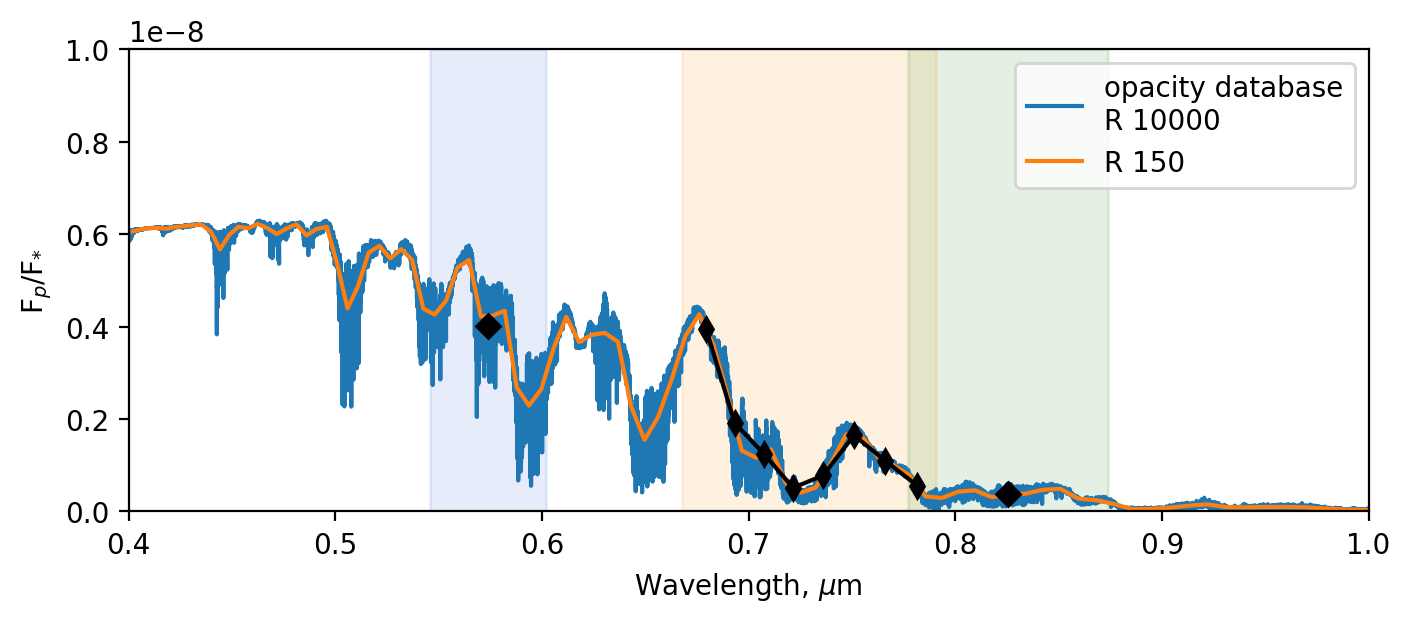

In [14]:
#re-sample the default higher resolution model to something easier to see
wno, fpfs = jdi.mean_regrid(spec['wavenumber'], spec['fpfs_total'], R=100) 

#plot up the spectrum with the default opacity database resolution and 
#with our regridded resolution
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
ax.plot(1e4/spec['wavenumber'], spec['fpfs_total'],label='opacity database\nR 10000')
ax.plot(1e4/wno, fpfs, linewidth=1.5, label='R 150')
ax.legend()
rtu.format_roman_cgi_spectrum(ax,0.0,1e-8)   # call our plot format function
rtu.plot_roman_cgi_obs(ax,spec)              # add the ~Roman-CGI observations

Now let's look at how much is coming from reflected light and how much is coming from thermal emission. The results dictionary contains the separate reflected light and thermal light results in keys `'fpfs_reflected'` and `'fpfs_thermal'`.

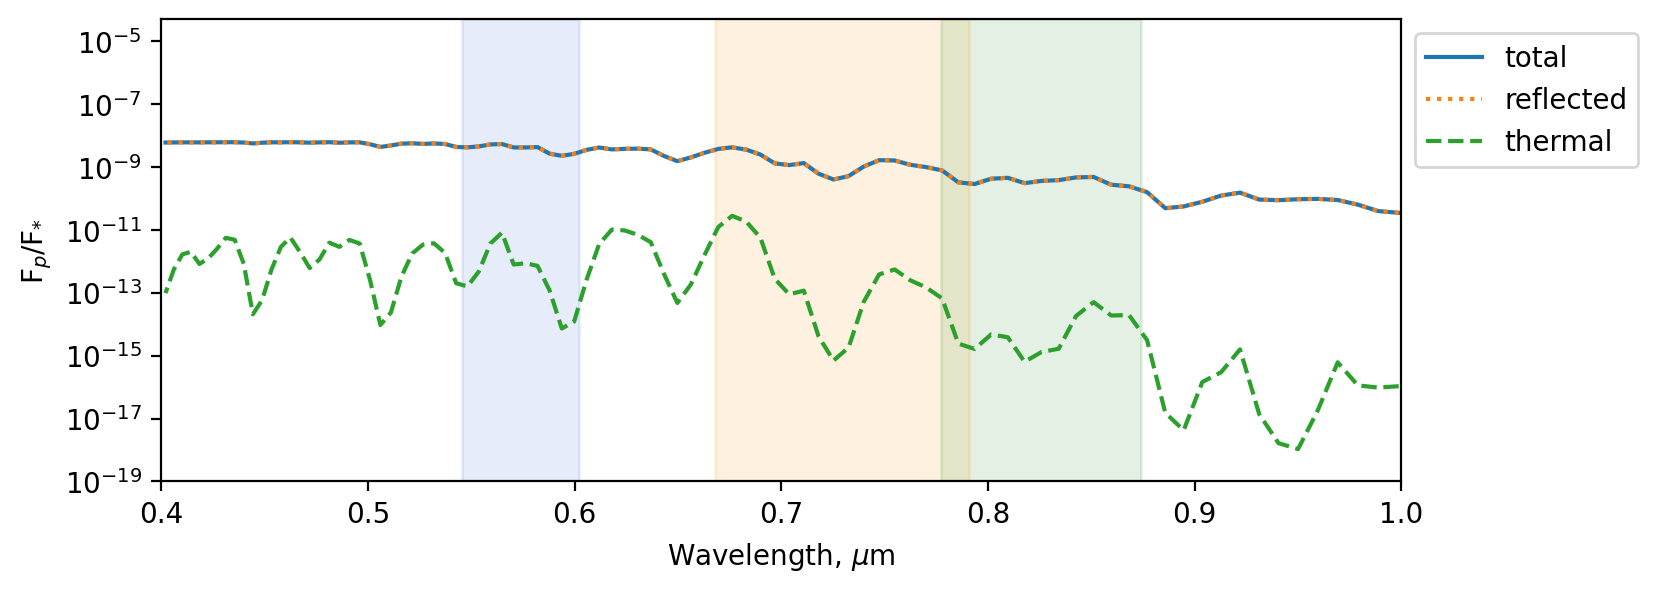

In [15]:
wno, refl = jdi.mean_regrid(spec['wavenumber'], 
                            spec['fpfs_reflected'],  #isolates the reflected light component
                            R=100)
wno, therm = jdi.mean_regrid(spec['wavenumber'], 
                             spec['fpfs_thermal'] , #isolates the thermal emission component
                             R=100)

#NOTE! from now on, whenever we regrid to R=100 from the 0.4-1.0 micron
#native opacity database resolution we'll just keep silently overwriting
#wno with the same values over again

#now plot them up
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
for y,ls,la in zip([fpfs,refl,therm],
                   ['-',':','--'],
                   ['total','reflected','thermal']):
    ax.semilogy(1e4/wno, y, linestyle=ls,label=la)
ax.legend(loc='upper left',bbox_to_anchor=(1,1))
rtu.format_roman_cgi_spectrum(ax,1e-19,5e-5)

The reflected-light component is essentially equal to the total value. Thermal flux is 3-10 orders of magnitude dimmer for our atmosphere across Roman-CGI wavelengths. This tells us we can safely ignore thermal flux when interpreting Roman-CGI observations in this regime. What if we move to a longer wavelength range than Roman-CGI? 

The wavelength range was set when we instantiated the RetrieveOpacities object, so the first step is to use opannection() to make a new RetrieveOpacities object extending to longer wavelengths

In [16]:
opa_ir = jdi.opannection(filename_db=opacity_db,    #pass in the same path to the opacity database as before
                        wave_range=[0.4,7.0])       #now raising the upper bound for the wavelength range

In [17]:
# --- EXPLORATION 1 ---------------------------------
#try re-computing a spectrum for this same case but now extending to 
#longer wavelengths. If you make a similar plot of total, reflected, 
#and thermal light components, does thermal emission ever become 
#significant for this ~Jupiter case?
#----------------------------------------------------

#initiate a new inputs instance


#set stellar and planetary parameters, pass star opa_ir


#define the atmosphere profile


#compute the spectrum, pass opa_ir and kwarg calculation='reflected+thermal'

 
#looping through 'total_fpfs', 'reflected_fpfs', and 'thermal_fpfs'  
#regrid to lower resolution and plot up results
#you'll want to set the y-axis scale to log, and adjust 
#xlim to extend to 7 microns


#----------------------------------------------------
#try repeating with different stellar properties 
#(Teff, Metallicity, Logg, radius). Do any of these impact 
#the relative contributions of reflected light and 
#thermal emission to the total planet-star flux ratio?
#----------------------------------------------------



### That covers the most basic PICASO usage. Now we'll get into more details and nuance with adding clouds, changing phase angle, and how to actually interpret spectral features.

[notebook top](#top) | [section top](#5Compute)

-----------
## <a id="6Grids"></a>6. Reading T-P profiles from two model grids

#### Sonora-Bobcat  -- for $T_{\textrm{int}}$ 200-2400 K, but ignoring irradiation and clouds, fixed to solar metallicity

Roman-CGI targets will range from cool temperatures ~150 K for the reflected-light targets, all the way up to >2400 K for the hottest of the self-luminous thermal emission dominated targets. We'll make use of PICASO's convenient interface with the **Sonora-Bobcat** model grid to compute spectra across this whole temperature range (Marley et al 2021 https://iopscience.iop.org/article/10.3847/1538-4357/ac141d). 


We downloaded a subset of the atmosphere profiles from this grid into the PICASO reference data during installation. The parameter space covers:

**Metallicity**: solar only (M/H = 0.0 dex) 

**C/O**: solar only (~0.485)

**$T_{\textrm{eff}}$ — 39 values (K)**

- 200–600 K in steps of 25 K
- 600–1000 K in steps of 50 K
- 1000–2400 K in steps of 100 K

**Surface Gravity — 10 values**
    
| g (m/s²) | log g (cgs) | Approx. object type |
|----------:|------------:|:--------------------|
| 17 | 3.23 | planet |
| 31 | 3.49 | planet / young BD|
| 56 | 3.75 | planet / young BD |
| 100 | 4.00 | planet / BD / young BD |
| 178 | 4.25 | BD / young BD |
| 316 | 4.50 | BD / young BD |
| 562 | 4.75 | BD / low-mass star |
| 1000 | 5.00 | BD / low-mass star |
| 1780 | 5.25 | low-mass star |
| 3160 | 5.50 | low-mass star |

**Note:** The combination Teff = 1600 K, log g = 4.25 (g = 178 m/s²) is missing from the local grid.


Sonora-Bobcat models conducted climate calculations for non-irradiated giant exoplanets or brown dwarfs assuming clear atmospheres and chemical equilibrium across a large parameter space of metallicities, surface gravities, and effective temperatures.  Recall some definitions from Zarah's lecture:

- **$T_{\textrm{eff}}$** : the temperature of an ideal blackbody that emits the same total radiation per unit surface area as the star/brown dwarf/planet. $L_{\textrm{Bol}} = 4\pi R^2 \sigma T_{\textrm{eff}}^4$

- **$T_{\textrm{eq}}$** : the theoretical blackbody temperature a planet would maintain if its absorbed stellar energy perfectly balances its emitted thermal radiation. It represents a "no-atmosphere," average global temperature, calculated solely based on the planet's distance from the star, stellar luminosity, and albedo (reflectivity)

- **$T_{\textrm{int}}$** : the effective temperature a planet would have if it received no external radiation from a star.

- $T_{\textrm{eff}}^4 \approx  T_{\textrm{eq}}^4 + T_{\textrm{int}}^4  $

The young hot directly imaged planets and substellar companions Roman-CGI will target are in the regime where $T_{\textrm{int}} \sim T_{\textrm{eff}}$. The old cold RV detected planets are in the regime where $T_{\textrm{eq}}$ contributes significantly to  $T_{\textrm{eff}}$.

Sonora-Bobcat is really most appropriate for the $T_{\textrm{int}} \sim T_{\textrm{eff}}$ regime, and even there it neglects some important processes like clouds and disequilibrium chemistry. Nevertheless, since it is one of the only grids that spans our parameter space of interest and already integrated with PICASO, we'll use for first-order pedagogical purposes.

Here is how to pull an atmosphere profile from the sonora model grid:

In [18]:
#set the path to the sonora profiles
#these were downloaded already along with picaso reference data
sonora_profile_db = os.path.join(os.getenv('picaso_refdata'),'sonora_grids', 'bobcat')

#start up a new inputs instance
sonora_inputs = jdi.inputs()
sonora_inputs.phase_angle(0)
sonora_inputs.gravity(mass=1.0,mass_unit=jdi.u.Unit('M_jup'),
                      radius=1.0,radius_unit=jdi.u.Unit('R_jup'))
sonora_inputs.star(opa, 5000, 0, 4.0,  
                   radius=1.0,  radius_unit=jdi.u.Unit('R_sun'),
                   semi_major=5.0, semi_major_unit=jdi.u.Unit('au'))

#now instead of using .atmosphere, we'll set our profile
#of temperatures, pressures, and abundances from the sonora models.
#the .sonora class function pulls the nearest model for the gravity 
#and temperature provided and uses it to set the atmosphere profile
#DataFrame
sonora_inputs.sonora(sonora_profile_db, 200) # we'll pick the coolest one to be most similar to our Jupiter base case

# now compute the spectrum, let's use the longer wavelength range
sonora_spec = sonora_inputs.spectrum(opa,
                                     calculation='reflected+thermal',
                                     full_output=True)


#let's look at the T-P profiles... the differences arise from
#models differing metallicities, T_int, irradiation levels, clouds
jpi.show(jpi.row(jpi.pt(sonora_spec['full_output'], plot_height=500),
                 jpi.pt(spec['full_output'], plot_height=500)))

#### Batalha+2018  -- for irradiated T = 150 K  and Jupiter-sized objects at a range of separations, metallicities, cloudiness

To supplement Sonora-Bobcat in the regime where $T_{\textrm{eq}}$ is a significant part of $T_{\textrm{eff}}$, you may also want to make use of the model grid from **Batalha+2018** (https://iopscience.iop.org/article/10.3847/1538-3881/aad59d). 

In their climate calculations, they and assume a sun-like host star and keep the planet gravity + internal temperature fixed to approximate Jupiter, then they vary metallicity and planet-star separation. Crucially, they include clouds in their calculations. The clouds are also post-processed to have a range of $f_{sed}$ values (meaning of $f_{sed}$ discussed more in the next section on clouds), making for three total grid axes.

**$T_{\textrm{int}}$**: 150 K

**log(g)**: 25 log(cgs)

**Stellar Flux**: Sun-like star

**C/O ratio**: ~solar

| Parameter | Symbol | Grid values |
|---|---|---|
| Metallicity | [M/H] | 0.0, 0.5, 1.0, 1.5, 1.7, 2.0 dex |
| Orbital separation | $d_{sep}$ | 0.5, 0.6, 0.7, 0.85, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0 AU |
| Cloud sedimentation efficiency | $f_{sed}$| 0.01, 0.03, 0.1, 0.3, 1, 3, 6 |

The roman_tutorial_utils module has a bespoke input function `read_batalha_profile` to easily read the Batalha+2018 grid and pass appropriate `DataFrames` to the `.atmosphere` and `.clouds` class functions. It can be called and added to an `inputs` object as follows:

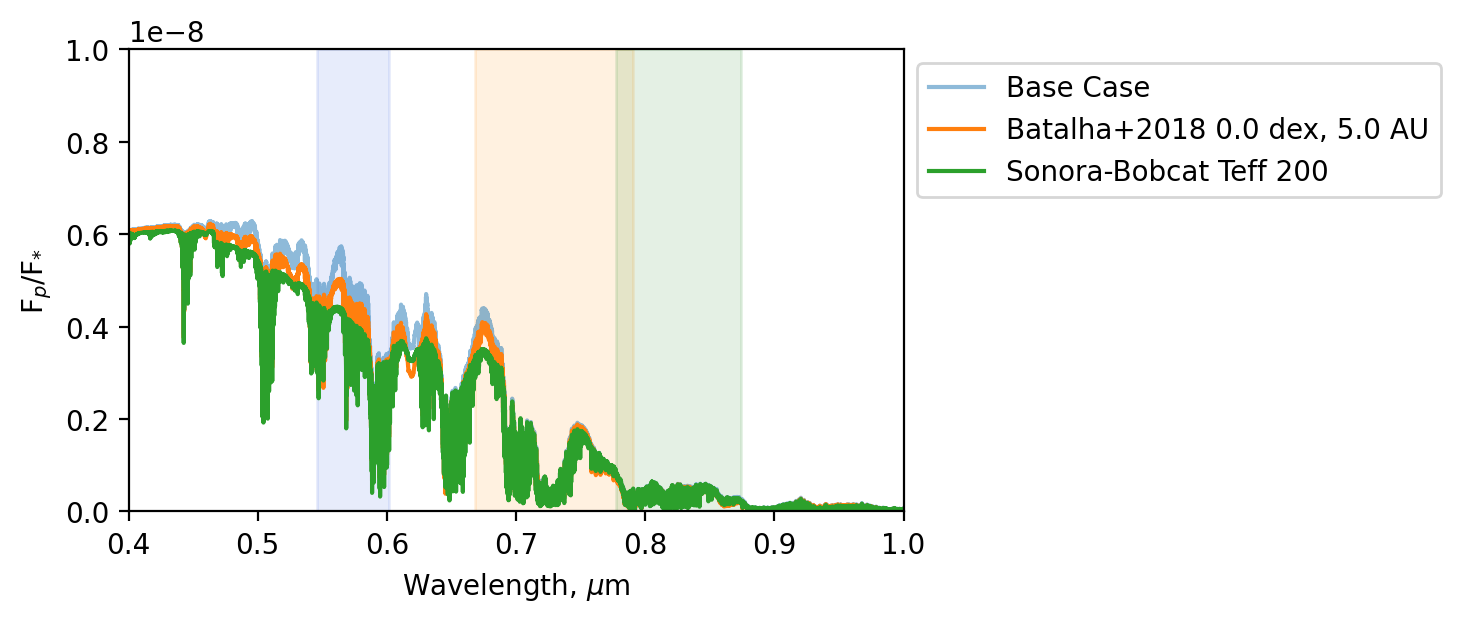

In [19]:
#load in the grid files
pt_df, cld_df = rtu.read_batalha_profile(0.0, # log metallicity in dex relative to solar
                                         5.0, # planet-star separation in AU
                                         6.0) # fsed <-- note that this only changes cld_df, not pt_df

#set up inputs object, pass atmosphere profile, and compute spectrum
batalha_inputs = deepcopy(sonora_inputs)
batalha_inputs.atmosphere(df=pt_df)
#batalha_inputs.clouds(df=cld_df) # skipping this for now!
spec_batalha = batalha_inputs.spectrum(opa,
                                       calculation='reflected+thermal',
                                       full_output=True)

#plot up results -- note we've ignored the Batalha+2018 clouds for now
fig=plt.figure(figsize=(5,3))
ax=plt.subplot(1,1,1)
plt.plot(1e4/spec['wavenumber'],spec['fpfs_reflected'],label='Base Case',alpha=0.5)
plt.plot(1e4/spec_batalha['wavenumber'],spec_batalha['fpfs_reflected'],label='Batalha+2018 0.0 dex, 5.0 AU')
plt.plot(1e4/sonora_spec['wavenumber'],sonora_spec['fpfs_reflected'],label='Sonora-Bobcat Teff 200')
rtu.format_roman_cgi_spectrum(ax,0,1e-8)
plt.legend(loc='upper left',bbox_to_anchor=(1,1))

Both Batalha+2018 and Sonora-Bobcat will be useful for the explorations and exercises in the remainder of the tutorial.

[notebook top](#top) | [section top](#6Grids)

-----------
## <a id="7Clouds"></a> 7. Clouds

First let's make a new `inputs` instance for the clear base case at full phase and make a new `inputs` instance for cloudy calculations. We'll go back to using the original `RetrieveOpacities` object with wavelengths from 0.4 to 0.9 microns.

In [20]:
#set up for the clear case, we could use deepcopy(model_inputs), 
#but let's run through the process one more time to solidify

#initialize
clear_inputs = jdi.inputs()
#specify gravity
clear_inputs.gravity(radius=1, radius_unit=jdi.u.Unit('R_jup'), 
                     mass = 1, mass_unit=jdi.u.Unit('M_jup'))
#specify stellar parameters
clear_inputs.star(opa,        #back to our original wavelength range
                  5000,       #Stellar Teff
                  0,          #Stellar metallicity
                  4.0,        #Stellar surface gravity
                  radius=1.0,  radius_unit=jdi.u.Unit('R_sun'), #Stellar radius
                  semi_major=5.0, semi_major_unit=jdi.u.Unit('au')) #planet-star separation
#set phase angle
clear_inputs.phase_angle(0.0)
#set atmosphere profile
clear_inputs.atmosphere(filename=jdi.jupiter_pt(), sep="\\s+")  


#set up for cloudy case begins the exact same way
#so we'll use deepcopy to instantiate an inputs()
#object with the same attributes 
cloudy_inputs = deepcopy(clear_inputs)

Similar to the atmosphere profile, the cloud properties are stored in `.inputs` as a `DataFrame` within a dictionary within another dictionary. There is a convenient function for setting this called `.clouds`, analogous to the `.atmosphere` function. The cloud profile `DataFrame` needs to provide a single scattering albedo, asymmetry parameter, and total extinction per layer. Unlike the atmosphere profile, all of these quantities are also wavelength dependent. 

You can specify cloud properties in a variety of ways:

- create a `DataFrame` on the spot and pass to the `.clouds` function
- read values in from a file with the `.clouds` function
- simple gray deck with no wavelength dependence for single scattering albedo, asymmetry parameter, or total extinction per layer
- use `virga` to get physically-motivated Eddy-Sed clouds consistent with your T-P profile

We will read ours from a file made to replicate Jupiter for now. Later, we'll experiment with gray clouds and Eddy-Sed clouds.

In [21]:
#fill in a cloud profile DataFrame based on information in a file by passing the
#filename keyword argument to .clouds . The header line of the file needs to contain
#specific coloumn names that picaso will look for.
cloudy_inputs.clouds(filename= jdi.jupiter_cld(), sep=r'\s+')
print('cloud information was read in from the file: ' + jdi.jupiter_cld()+'\n')
print('here are the first five lines from the file to see the format:\n')
os.system('head -5 ' + jdi.jupiter_cld())

cloud information was read in from the file: /Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/base_cases/jupiterf3.cld

here are the first five lines from the file to see the format:

lvl wv opd g0 w0 sigma
1 1 0.0 0.0 0.0 0.0
1 2 0.0 0.0 0.0 0.0
1 3 0.0 0.0 0.0 0.0
1 4 0.0 0.0 0.0 0.0


0

In this case the cloud file defines the cloud properties with pressure levels that correspond to the default PICASO pressure grid, so they are just integer indices. If your cloud is defined on a different pressure grid, then your cloud file must have a column labeled pressure instead of lvl and the `.clouds` function will interpolate your cloud properties to the correct pressure grid to match the atmosphere profile in your inputs object.

In [22]:
#take a quick look at how picaso stored the profile we read in:
print(type(cloudy_inputs))
print(type(cloudy_inputs.inputs))
print(type(cloudy_inputs.inputs['clouds']))
print(type(cloudy_inputs.inputs['clouds']['profile'] ))

cloudy_inputs.inputs['clouds']['profile'] [:4]

<class 'picaso.justdoit.inputs'>
<class 'dict'>
<class 'dict'>
<class 'pandas.core.frame.DataFrame'>


,lvl,wv,opd,g0,w0,sigma
0,1,1,0.0,0.0,0.0,0.0
1,1,2,0.0,0.0,0.0,0.0
2,1,3,0.0,0.0,0.0,0.0
3,1,4,0.0,0.0,0.0,0.0


Recall some definitions from Zarah's lecture:

- **optical depth per layer**, the attenuation of light between the lower and upper boundary of the layer
- **asymmetry parameter**, $g_0$, the intensity-weighted mean cosine of cloud scattering, captures the relative strength of forward scattering to back scattering 
- **single scattering albedo**, $\omega_0$, the ratio of scattering to total extinction by cloud particles

Cloud particle sizes, shapes, and materials alter all of these, and thus imprint information into the spectrum.

In [23]:
print('nwno_cloud:',len(np.where(cloudy_inputs.inputs['clouds']['profile']['lvl']==1)[0]))
print('nlayer_cloud:', len(np.where(cloudy_inputs.inputs['clouds']['profile']['wv']==1)[0]))
print('nlayer_atmosphere:', len(cloudy_inputs.inputs['atmosphere']['profile']['pressure']))

nwno_cloud: 196
nlayer_cloud: 60
nlayer_atmosphere: 61


The number of cloud profile levels must be one less than the number of atmosphere profile grid points for the optical depth per layer to line up. Users can specify their own wavenumber grid. This file has the PICASO default of 196 wavenumbers.

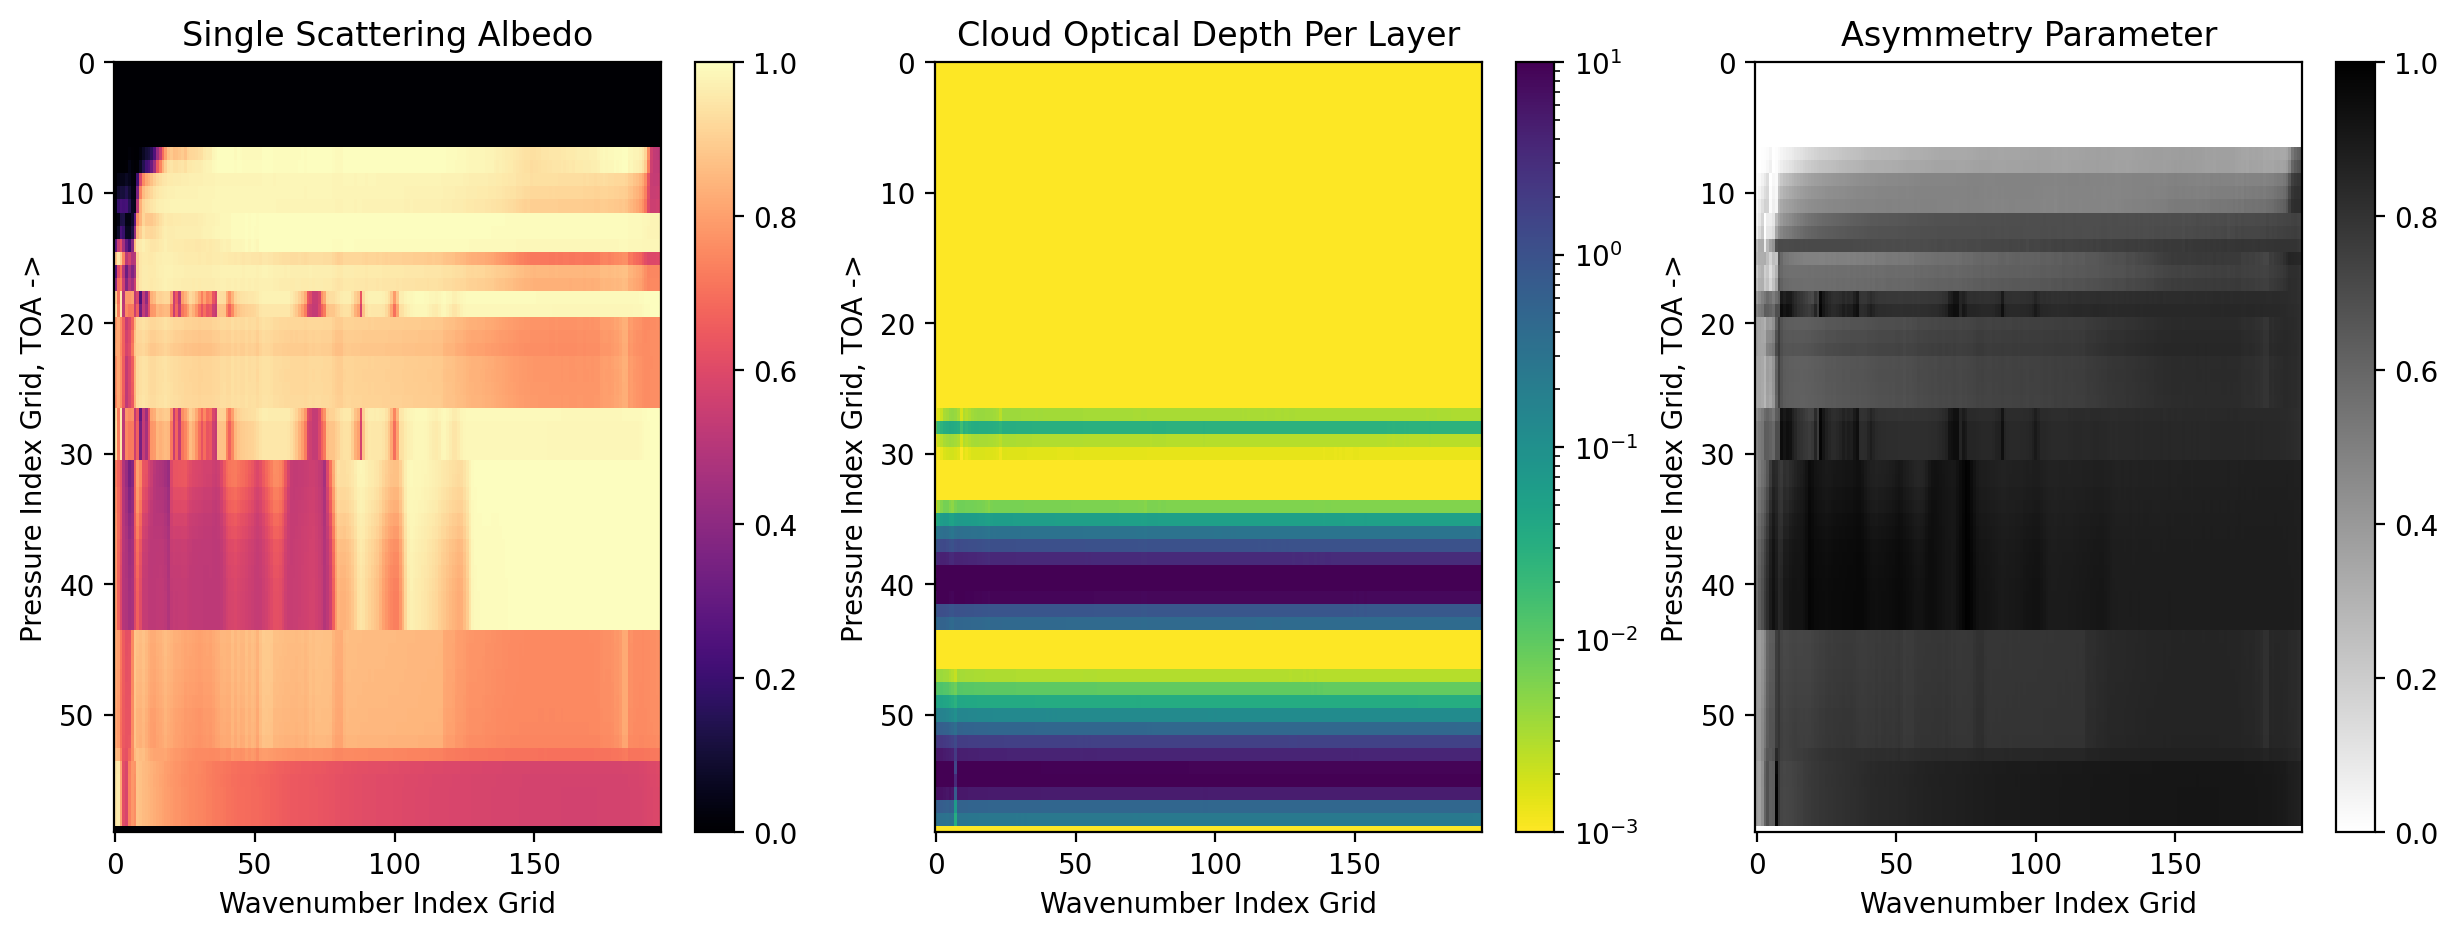

In [24]:
#picaso has a convenient function for taking a more careful look at the clouds we added across pressure 
#space and wavelength space
nwno = 196 #this is the default number for A&M cloud code
nlayer = 60 #one less than the number of PT points in your atmosphere profile
fig = jpi.plot_cld_input(nwno, nlayer,filename=jdi.jupiter_cld(),sep=r'\s+')

We can see from the center plot that we have added three distinct layers of clouds: water is deepest, then ammonia, then a thin methane cloud on top. There is a fair amount of wavelength dependence to the clouds optical properties.

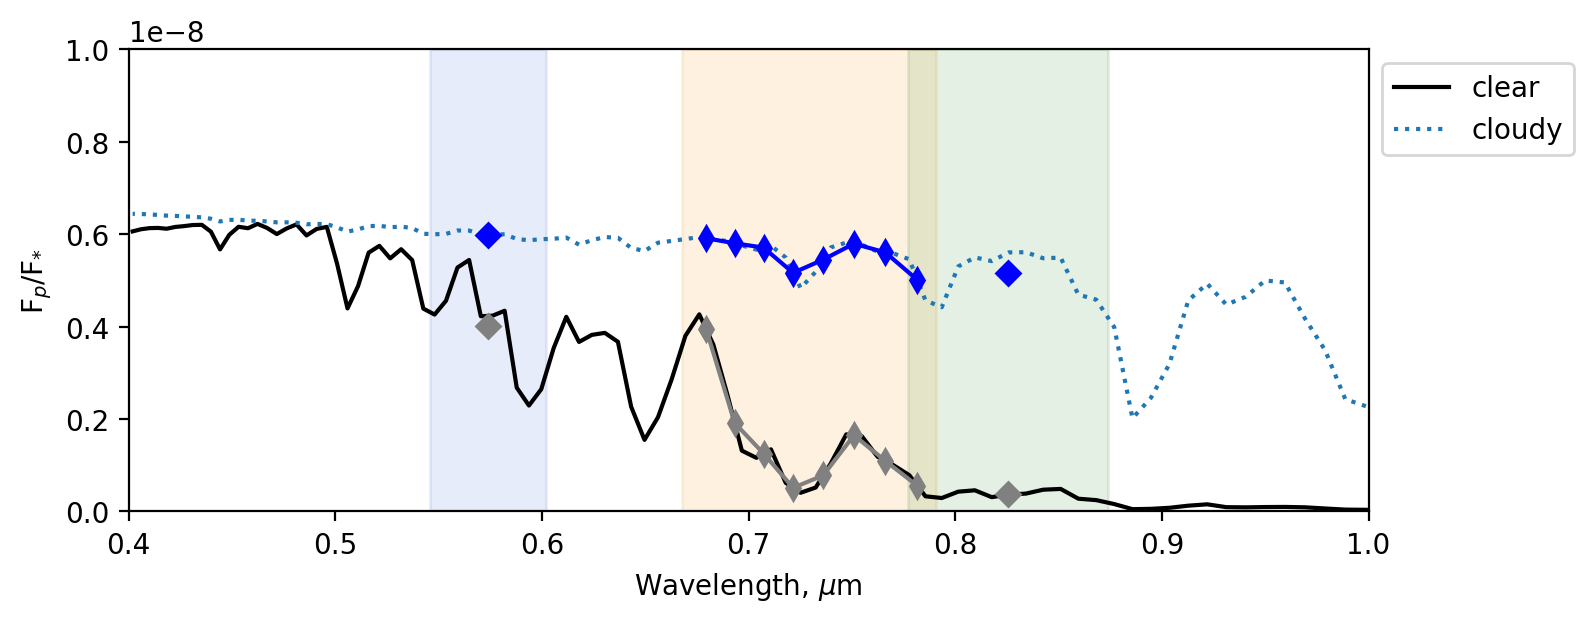

In [25]:
#compute and re-grid spectra in the same way
spec_clear = clear_inputs.spectrum(opa,                 
                                   calculation='reflected+thermal')   
wno, fpfs_clear = jdi.mean_regrid(spec_clear['wavenumber'], 
                                  spec_clear['fpfs_total'] , 
                                  R=100)

spec_cloudy = cloudy_inputs.spectrum(opa,                 
                                     calculation='reflected+thermal')   
wno, fpfs_cloudy = jdi.mean_regrid(spec_cloudy['wavenumber'], 
                                   spec_cloudy['fpfs_total'] , 
                                   R=100)
#quick plot to compare the two:
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
ax.plot(1e4/wno, fpfs_clear, linewidth=1.5, color='k',label='clear')
ax.plot(1e4/wno, fpfs_cloudy,label='cloudy',linestyle=':')
rtu.plot_roman_cgi_obs(ax,spec_clear,color='gray')
rtu.plot_roman_cgi_obs(ax,spec_cloudy,color='blue')
rtu.format_roman_cgi_spectrum(ax,0.0,1e-8)
ax.legend(loc='upper left',bbox_to_anchor=(1,1))

> That is a big difference, especially in Roman-CGI bands 3 and 4! 

In [26]:
# --- EXPLORATION 2 ---------------------------------------------
#How do these clouds influence the planet-star flux ratio and the
#balance of thermal vs reflected light across the whole 0.4-7 micron range?
# ---------------------------------------------------------------

#initiate a new inputs object with the same properties as clear_inputs
#but this time pass the .star function a RetrieveOpacities object
#extending to 7 microns



#add clouds



#compute spectrum using the longer wavelength RetreiveOpacities object



#plot the total planet-star flux ratio as well as the separate thermal emission
#flux ratio and reflected-light flux ratio, compare what you found in excercise 1
#for the clear case




> Clouds can have dramatically different impacts at different wavelengths. The Jupiter base case cloud extends the wavelength range where the reflected light component is non-negligible to as long as 6 microns. 

### Now let's look at two parameterized ways to add in clouds: 
- arbitrarily-placed **gray cloud** 
- using the physically-motivated **Eddy-Sed** cloud model

We'll start with the much simpler arbitrarily-placed **gray cloud**. The spatial location of the clouds is set by a central cloud pressure and a width in pressure space. The optical impact of the cloud is set by one single scattering albedo, one asymmetry parameter, and one optical depth per layer which are applied to all wavelengths and in all layers of the cloud.

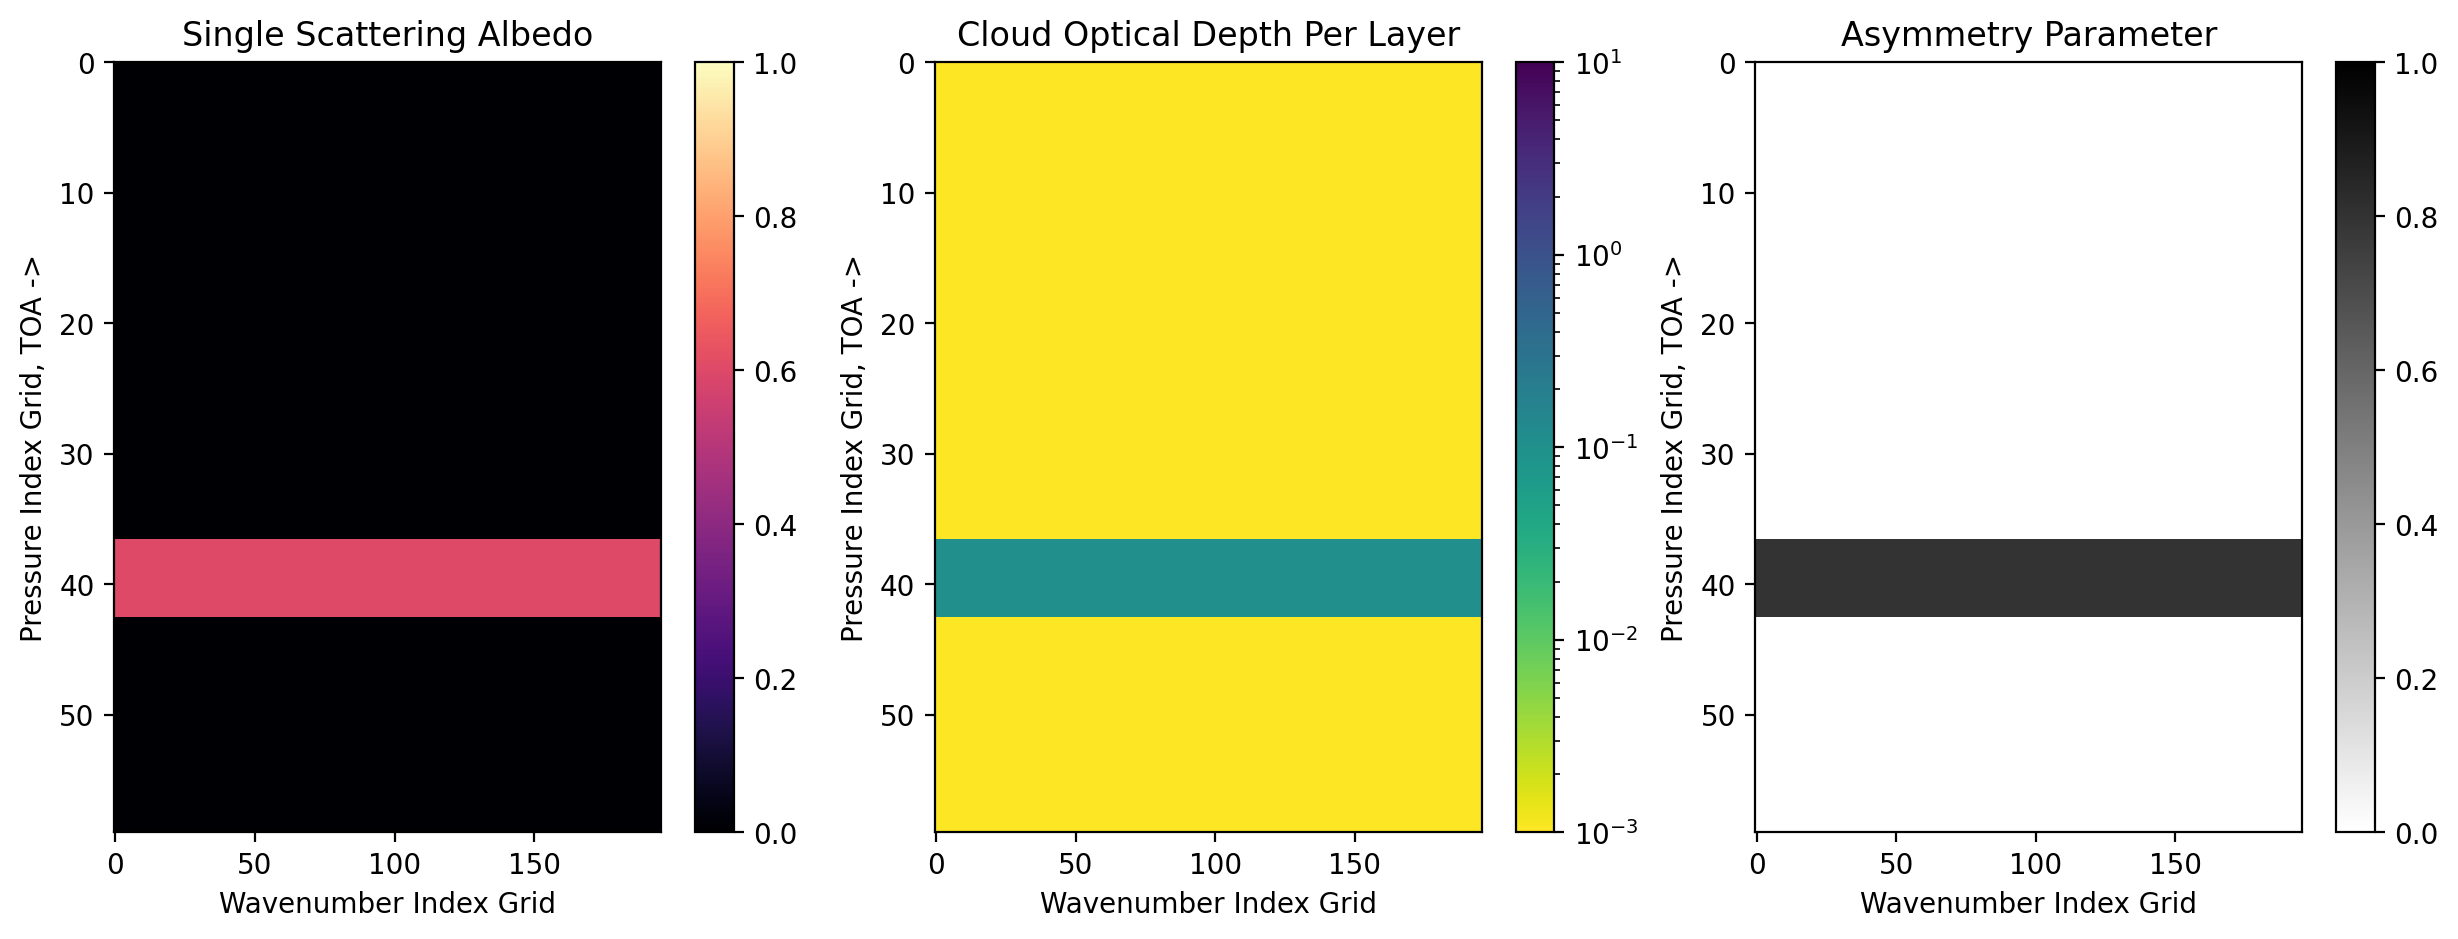

In [27]:
#create new inputs object and set parameters
gray_inputs = deepcopy(clear_inputs)

#different method of adding the cloud profile
gray_inputs.clouds( w0=[0.6],  # single-scattering albedo
                    opd=[0.1], # optical-depth per layer
                    g0=[0.8],  # asymmetry parameter
                    p = [0.5], # log10 of the central cloud pressure in bars
                    dp=[1.0])  # with of cloud pressures in log10


#Before looking at the spectrum, let's compare the gray cloud properties to the 
#non-gray, multi-level cloud from before
fig = jpi.plot_cld_input(nwno, nlayer, df=gray_inputs.inputs['clouds']['profile'])

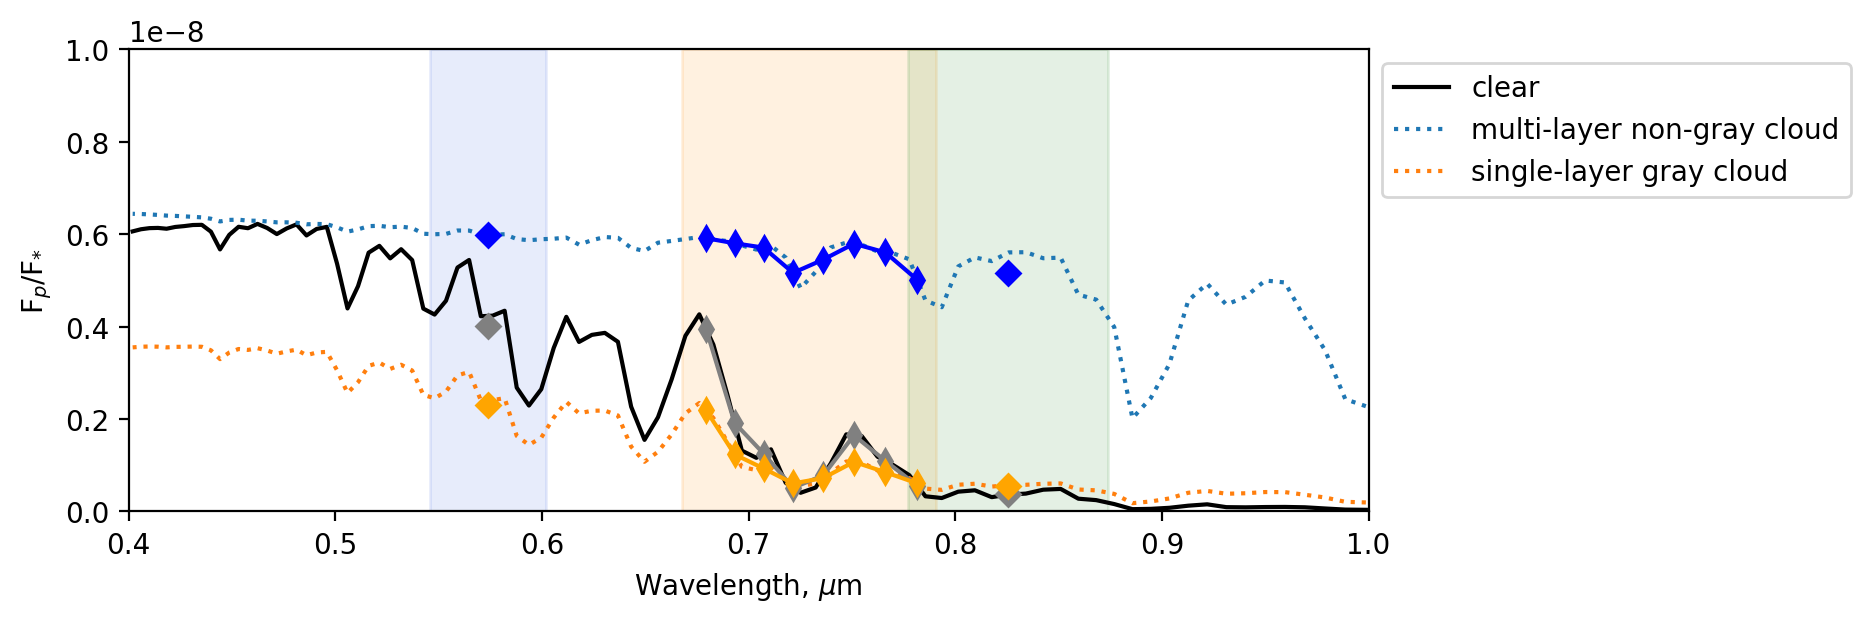

In [28]:
#compute spectrum and regrid 
spec_gray = gray_inputs.spectrum(opa,calculation='reflected+thermal')
wno_gray, fpfs_gray = jdi.mean_regrid(spec_gray['wavenumber'], spec_gray['fpfs_total'], R=100)

#check out the results
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
ax.plot(1e4/wno, fpfs_clear, linewidth=1.5, color='k',label='clear')
for s,l in zip([fpfs_cloudy,fpfs_gray],
               ['multi-layer non-gray cloud','single-layer gray cloud']):
    ax.plot(1e4/wno, s,label=l,linestyle=':')
ax.legend(loc='upper left',bbox_to_anchor=(1,1))

rtu.plot_roman_cgi_obs(ax,spec_clear,color='gray')
rtu.plot_roman_cgi_obs(ax,spec_cloudy,color='blue')
rtu.plot_roman_cgi_obs(ax,spec_gray,color='orange')
rtu.format_roman_cgi_spectrum(ax,0.0,1e-8)

This gray cloud is actually dimmer than a clear atmosphere in most bands. Roman-CGI bandpasses are sensitive to the detailed properties of clouds, but they can also be degenerate.  

Now let's look at the more physically motivated **Eddy-Sed** model for clouds. The appropriate choices of single-scattering albedo, asymmetry factor, and optical depth for clouds depend on what material the clouds are made of and the size of the cloud particles. 

Eddy-Sed balances the upward turbulent mixing of condensate and vapor against the downward transport of condensate due to sedimentation in order to determine the equilibrium cloud particle size distribution as a function of altitude (Ackerman & Marley 2001 https://ui.adsabs.harvard.edu/abs/2001ApJ...556..872A/abstract).

$-K_{zz}\frac{\partial q_t}{\partial z} - f_{sed}w_*q_c$ = 0

where $z$ is the vertical spatial coordinate, $-K_{zz}$ is the vertical mixing strength in cm$^2$/s, $q_t$ is the total mixing ratio of the cloud species in both vapor and condensed form, $q_c$ is the mixing ratio of the cloud species in condensed form, and $f_{sed}$ is the ratio of the mass-weighted droplet sedimentation velocity to $w_*$, the convective velocity scale. 

PICASO uses an accompanying package called `virga` to handle most cloud-related calculations. 

In [29]:
#start by importing virga
from virga import justdoit as vj
from virga import justplotit as cldplt
import astropy.units as u
import pandas as pd

First we need to tell PICASO and virga where to find the database which contains how different species optical properties (single-scattering, total extinction, asymmetry factor) depend on particle size and size distribution. These are all pre-calculated with Mie theory and stored in tables we downloaded earlier.

In [30]:
virga_path = os.path.join(os.getenv('picaso_refdata'), 'virga')
print(virga_path)

/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/virga


We'll do nearly the same creation of an `inputs` object as before. `virga` calculations use the same atmosphere profile as spectral calculations, but they also need information about **vertical mixing** throughout the atmosphere. We add this to the atmosphere profile `DataFrame` in a column called `'kz'` before calling the `.atmosphere` class function. 

Virga also needs to know the **metallicity** of the atmosphere and the **mean-molecular weight** of the atmosphere, so we'll specify that.

In [31]:
virga_inputs = deepcopy(clear_inputs) # our fiducial clear model

#add kz to the atmosphere profile
df_atmo = pd.read_csv(jdi.jupiter_pt(), sep=r'\s+')
virga_inputs.inputs['atmosphere']['profile']['kz'] = [1e8]*df_atmo.shape[0]

metallicity = 1 #atmospheric metallicity relative to Solar, this is used to determine how much cloud material is available, qt
mean_molecular_weight = 2.2 #atmospheric mean molecular weight in atomic mass units 

Now we'll call the `.virga` function to run an Eddy-Sed calculation for water clouds in our atmosphere profile. $f_{sed}$ is passed in as a keyword argument. This function both returns the results and stores them as the appropriate `DataFrame` in the `inputs` object. 

In [32]:
cld_virga = virga_inputs.virga(['H2O'],        #we are using only water, but this can be a list of multiple cloud species
                               virga_path,     #filepath pointing to the database of Mie Coefficients
                               fsed=2,         #sedimentation efficiency
                               mh=metallicity, #atmospheric metallicity relative to Solar 
                               mmw=mean_molecular_weight) #atmospheric mean molecular weight in atomic mass units

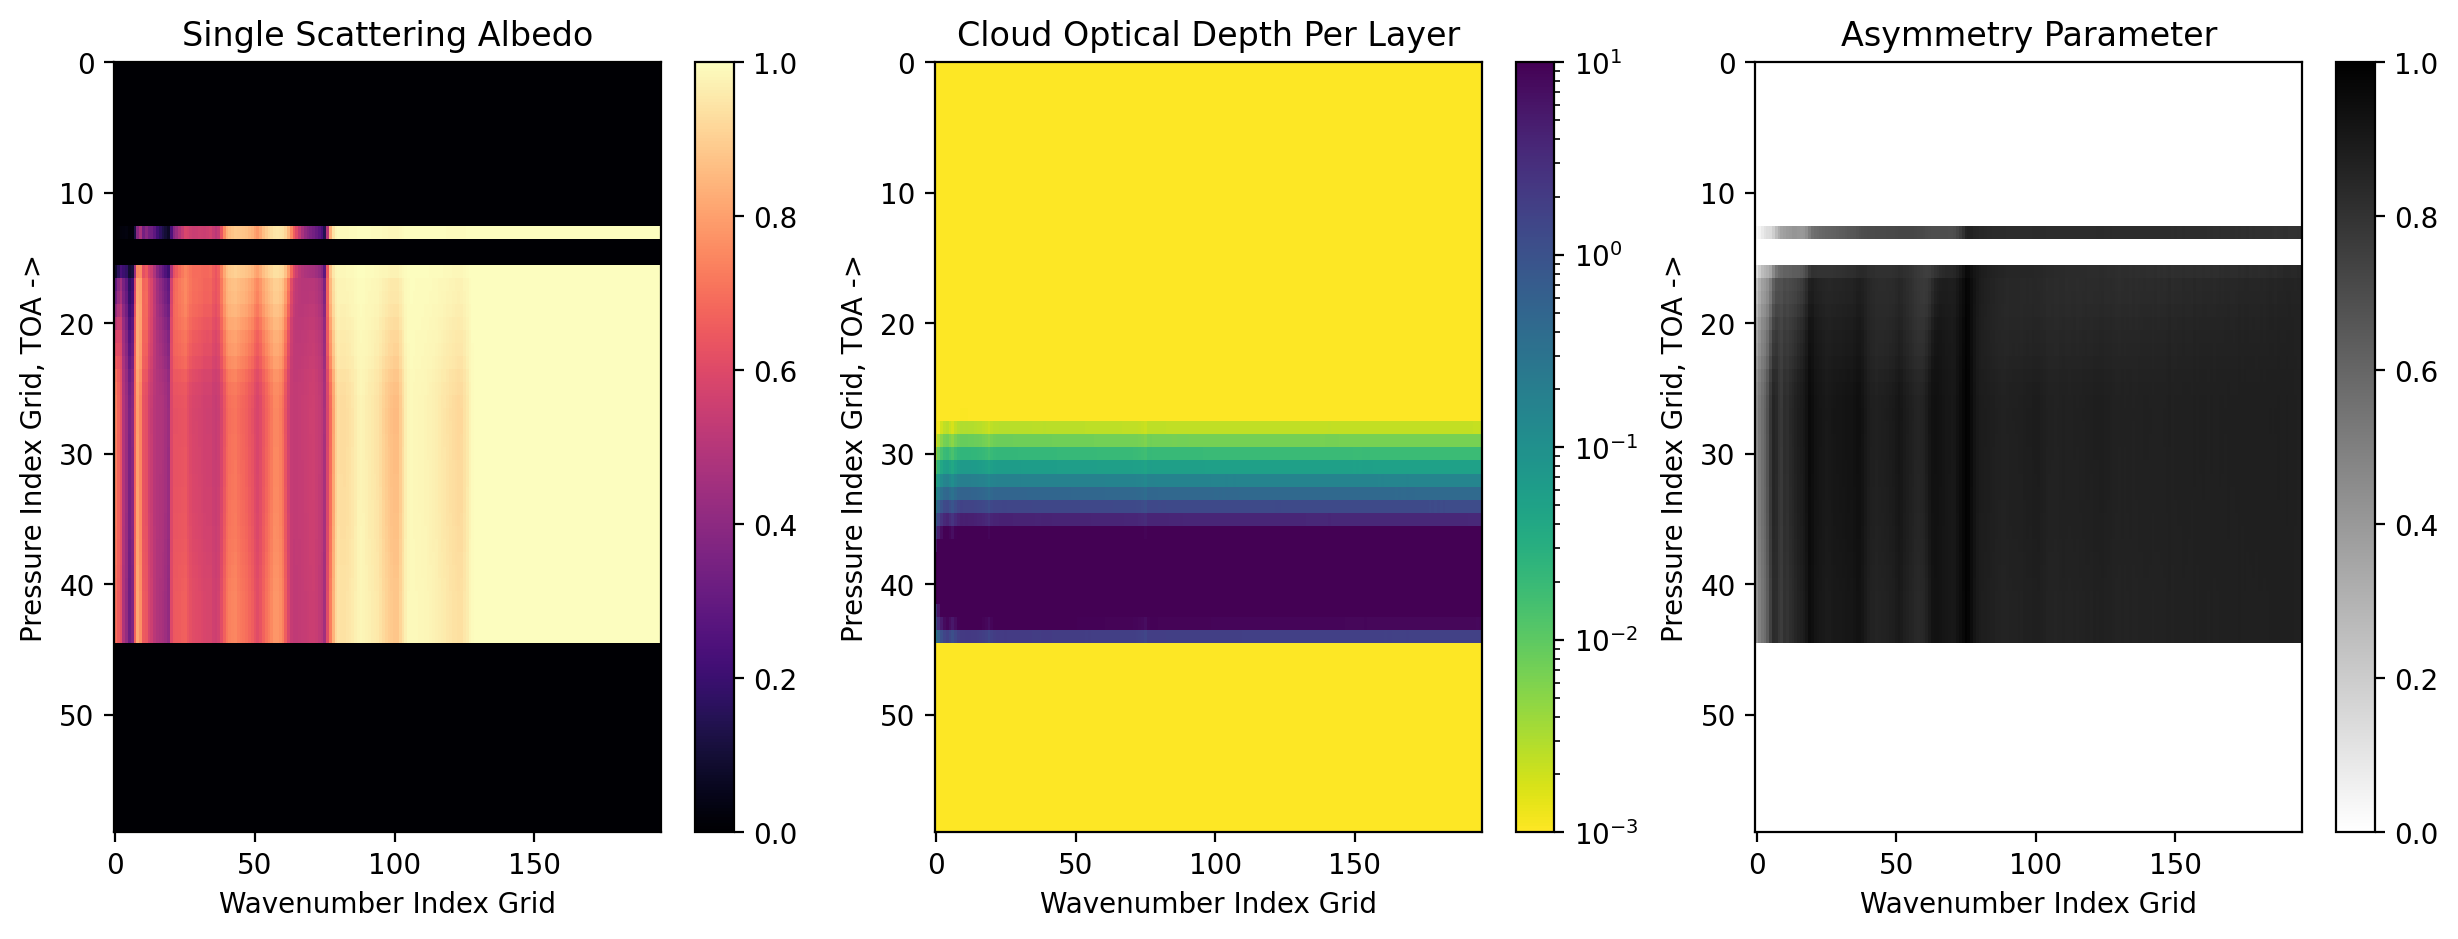

In [33]:
#examine cloud input figures
fig3 = jpi.plot_cld_input(nwno, nlayer, df=virga_inputs.inputs['clouds']['profile'])

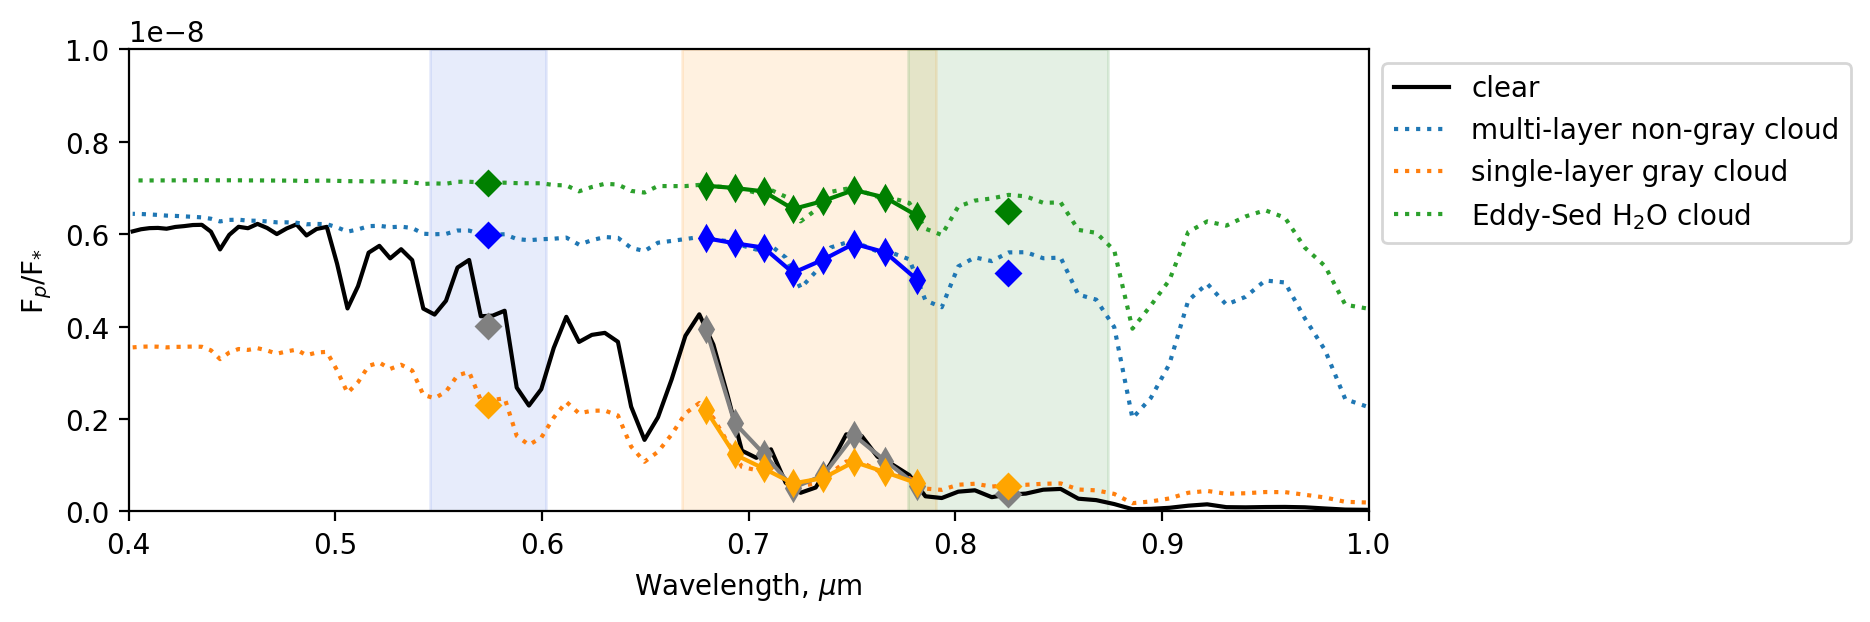

In [34]:
#compute spectrum and regrid to R~100
spec_virga = virga_inputs.spectrum(opa,calculation='reflected+thermal')
wno_virga, fpfs_virga = jdi.mean_regrid(spec_virga['wavenumber'], spec_virga['fpfs_total'], R=100)

#check out the results
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
ax.plot(1e4/wno, fpfs_clear, linewidth=1.5, color='k',label='clear')
for s,l in zip([fpfs_cloudy,fpfs_gray,fpfs_virga],
               ['multi-layer non-gray cloud','single-layer gray cloud','Eddy-Sed H$_2$O cloud']):
    ax.plot(1e4/wno, s,label=l,linestyle=':')

rtu.plot_roman_cgi_obs(ax,spec_clear,color='gray')
rtu.plot_roman_cgi_obs(ax,spec_cloudy,color='blue')
rtu.plot_roman_cgi_obs(ax,spec_gray,color='orange')
rtu.plot_roman_cgi_obs(ax,spec_virga,color='green')
rtu.format_roman_cgi_spectrum(ax,0.0,1e-8)
ax.legend(loc='upper left',bbox_to_anchor=(1,1))

> These are much brighter again, more like the Jupiter base case than the gray clouds

Like gas-phase chemistry, clouds are also highly sensitive to temperature. You can check which species might be relevant for your particular planet's T-P profile with virga: 

In [35]:
profile = sonora_inputs.inputs['atmosphere']['profile']
recommended = vj.recommend_gas(
                              profile['pressure'],     # bars
                              profile['temperature'],  # K
                              mh=1,                    # metallicity (solar = 1), this is not is in log10!!
                              mmw=2.2,                 # mean molecular weight
                              plot=True)               # optionally shows condensation curves vs P-T
print(recommended)

['CaTiO3', 'Cr', 'H2O', 'KCl', 'Mg2SiO4', 'MgSiO3', 'MnS', 'NH3', 'Na2S', 'SiO2', 'ZnS']


That looks like a lot of cloud species to account for! Luckily some of these species can often be safely ignored, similar to how certain gaseous molecular opacities dominate. Things like water, methane, ammonia, iron, and silicates (Mg2SiO4, MgSiO3, SiO2) have an order of magnitude more material to work with than other species. Or if a cloudbase is very deep in the atmosphere, well below the photosphere, it won't impact spectra. For reference, `virga` assumes the following properties for available cloud species.  

| Species | Mass mixing ratio | Mol. Weight (g/mol) | Grain Density (g/cm³) |
|---------|-------------:|--------------------:|---------------------:|
| H₂O | 6.169 × 10⁻³ | 18.0 | 0.930 |
| CH₄ | 3.564 × 10⁻³ | 16.0 | 0.490 |
| SiO₂ | 1.645 × 10⁻³ | 60.0 | 2.648 |
| Mg₂SiO₄ | 1.959 × 10⁻³ | 140.7 | 3.214 |
| MgSiO₃ | 1.333 × 10⁻³ | 100.4 | 3.192 |
| Fe | 1.293 × 10⁻³ | 55.8 | 7.875 |
| NH₃ | 1.035 × 10⁻³ | 17.0 | 0.840 |
| CaAl₁₂O₁₉ | 2.671 × 10⁻⁴ | 667.8 | 7.150 |
| CaTiO₃ | 1.549 × 10⁻⁴ | 135.7 | 3.987 |
| Na₂S | 1.185 × 10⁻⁴ | 78.1 | 1.856 |
| Al₂O₃ | 1.154 × 10⁻⁴ | 102.0 | 3.987 |
| MnS | 2.139 × 10⁻⁵ | 87.0 | 4.000 |
| Cr | 2.096 × 10⁻⁵ | 52.0 | 7.150 |
| KCl | 8.635 × 10⁻⁶ | 74.5 | 1.990 |
| TiO₂ | 6.145 × 10⁻⁶ | 80.0 | 4.250 |
| ZnS | 3.367 × 10⁻⁶ | 97.5 | 4.040 |

*Mass mixing ratio is for solar metallicity (M/H = 1) and mean molecular weight = 2.2. Values scale linearly with metallicity. Source: Lodders (2003, 2010), Morley et al. (2012, 2024).*

In [36]:
# --- EXPLORATION 3 ----------------------------
#Investigate how changes to one or several of the 
#cloud parameters impact spectra in  Roman-CGI bandpasses. 
#(w0, g0, opd for gray clouds; 
#fsed, Kzz, and species for Eddy-Sed clouds) 
#
#What about at longer wavelengths?
#
#Use Sonora-Bobcat models and virga's reccomend_gas() function to investigate
#which clouds matter across different internal temperatures, 
#you could pick temperatures and surface gravities relevant to Roman-CGI targets 
#based on the table in the A_introduction notebook
# --------------------------------------------



> Clouds will be important for pretty much all the Roman-CGI targets! Water, ammonia, and methane for cool reflected-light targets and iron+silicate clouds for self-luminous targets.

For more information about clouds, see: 

- picaso/docs/notebooks/A_basics/2_AddingClouds.py.
- picaso/docs/notebooks/C_clouds/1_PairingPICASOToVIRGA.py and the virga documentation.

There are some new more complex abilities added in like fractal aggregates instead of spherical particles, and some handy cloud parameterizations that are more sophisticated than gray but not so complex as Eddy-Sed.

[notebook top](#top)  |  [section top](#7Clouds)

-----------
## <a id="8Interpreting"></a> 8. Tools for interpreting spectral features

As an astrophysicist, you ultimately want to recover the information spectra encode about a distant object's atmosphere. PICASO has some built-in functionality for digging in to what opacity sources shape spectra at different wavelengths, which pressure levels flux tends to originate from at different wavelengths, and what the temperatures might be. This is helpful for predicting information content when planning observations/missions and for interpreting observations once you have collected them. Let's look at several of these tools.

### Tool \# 1: Comparing spectra with and without a particular opacity source.

This is analogous to what we did earlier plotting both clear and cloudy atmospheres calculated assuming the exact same chemistry and T-P profiles. Rather than adding and removing clouds, we can add and remove molecular species.

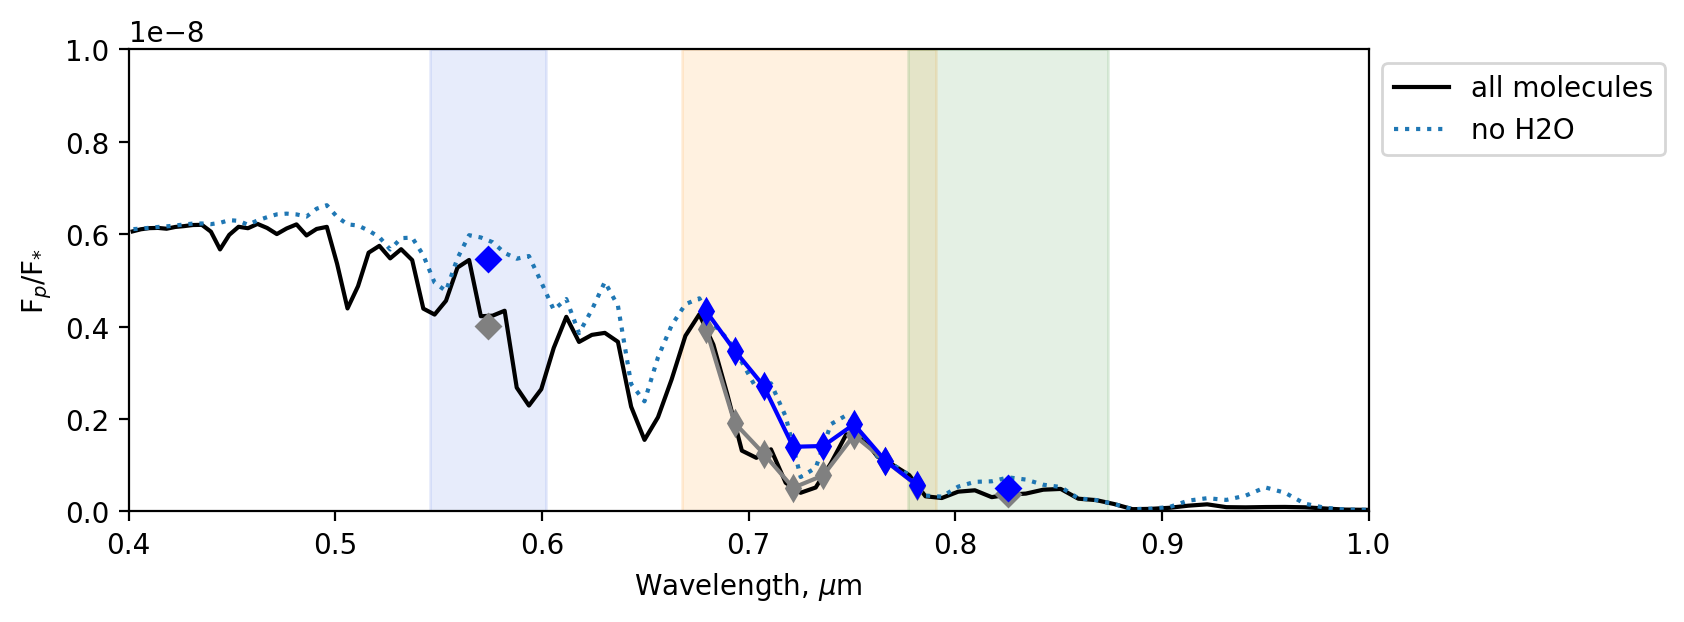

In [37]:
# re-specify the atmospheric profile in model_inputs(), now setting water abundances to zero everywhere
model_inputs.atmosphere(filename=jdi.jupiter_pt(), 
                        exclude_mol=['H2O'], 
                        sep="\\s+")

# re-compute reflected-light spectrum and save to a different output
spec_noH2O = model_inputs.spectrum(opa,calculation='reflected+thermal')

# re-sample to lower resolution for easier visualization
wno_noH2O, fpfs_noH2O = jdi.mean_regrid(spec_noH2O['wavenumber'], 
                                        spec_noH2O['fpfs_total'], R=100)

# plot the two spectra with and without water opacity included
# wavelengths were they differ are sensitive to water abundance
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
ax.plot(1e4/wno, fpfs, linewidth=1.5, color='k',label='all molecules')
ax.plot(1e4/wno_noH2O, fpfs_noH2O,label='no H2O',linestyle=':')
rtu.format_roman_cgi_spectrum(ax,0.0,1e-8)
rtu.plot_roman_cgi_obs(ax,spec,color='gray')
rtu.plot_roman_cgi_obs(ax,spec_noH2O,color='blue')
ax.legend(loc='upper left',bbox_to_anchor=(1,1,))

> Looks like water is important since we see big changes between the two lines at lots of wavelengths.

In [38]:
# --- EXPLORATION 4 -------------------------------
#Search for other spectrally significant molecules. 
#Recall that you can list all the molecules in the opacity database
#with opa.molecules
#
#If you add in clouds are the same molecules still spectrally significant?
#
#What if you change the T-P profile to other Sonoroa-Bobcat or
#Batlha+2018 models?
# --------------------------------------------------



> Looks like the only other important molecule for the Jupiter-like base case is methane, which has a little impact on band 4. None of the molecules seem to shape the spectrum at ~0.4-0.425 and ~0.75-0.77 microns. We'll see in a moment that this is because Rayleigh scattering dominates in both places.

> Changing the T-P profile should show that chemistry is *highly* temperature dependent! Changing metallicity and surface gravity also has some impact. 

### Tool \# 2: $\tau$=1 surface

For a given atmosphere profile and optionally cloud profile stored in an inputs object, PICASO can calculate the pressure level where each opacity source reaches an optical depth of tau=1.0 from the top of the atmosphere down. This gives a sense of what opacity source will shape the spectrum at a given wavelength for both reflected light and thermal emission. 
- For thermal emission it also marks the median pressure layer where photons escape from as a function of wavelength. 
- For reflected light where stellar flux is actually traversing the atmospheric column twice, this can still provide information about the relative depths into the atmosphere photons at different wavelengths reach will penetrate and re-emerge from.



In [39]:
#let's go back to our Jupiter-like example for this.
contribution_out = jdi.get_contribution(model_inputs, opa, at_tau=1.0)
jpi.show(jpi.molecule_contribution(contribution_out, opa))


> Here we can see that the wavelengths unimpacted by molecular absorption (at ~0.4-0.425 and ~0.75-0.77 microns) are likely shaped by Rayleigh scattering

In [40]:
# --- EXPLORATION 5 -------------------------
#Take a look at the tau=1 plot and corresponding spectrum for 
#Batalha+2018 models with a variety of cloud parameters, metallicities
#and temperatures
#
#Do you notice any patterns for when clear molecular absorption 
#features appear in spectra vs when spectra look flat?
# -------------------------------------------



### Tool \#3: Brightness temperature and comparing thermal spectra to black-bodies

Beyond what molecules and cloud species are present, we want to know about the planets' T-P profile. Spectra contain the most information about atmospheric layers where emitted photons start to actually escape out the top of atmosphere, the so-called **photosphere**. Below the photosphere, photons are absorbed and re-emitted in another direction. Above the photosphere, photons just freely stream past atmospheric material without interacting. Since opacities depend on wavelength, so does the photospheric pressure. 

Since our models assume **LTE**, the emission at a given layer follows  a black body curve. One tool for looking at which layers photons in your models are escaping from is to compare your spectrum to black body curves for temperatures of each of your atmospheric layers. PICASO's plotting package has a function to do this.

In [41]:
#let's use a warmer model for this and extend to ir...
sonora_inputs = jdi.inputs()
sonora_inputs.phase_angle(0)
sonora_inputs.gravity(mass=10.0,mass_unit=jdi.u.Unit('M_jup'),
                      radius=1.5,radius_unit=jdi.u.Unit('R_jup'))
sonora_inputs.star(opa_ir, 5000, 0, 4.0,  
                   radius=1.0,  radius_unit=jdi.u.Unit('R_sun'),
                   semi_major=5.0, semi_major_unit=jdi.u.Unit('au'))
sonora_inputs.sonora(sonora_profile_db, 1700) 
sonora_spec = sonora_inputs.spectrum(opa_ir,
                                     calculation='reflected+thermal',
                                     full_output=True)

#call the plotting routine
jpi.show(jpi.flux_at_top(sonora_spec, pressures=[3.0,1.0,0.3,0.1,0.03],
                         R=100,  plot_width=500, plot_height=400))

This object emits flux from as deep as ~10 bars. Most of the flux emerges from 10-0.01 bars. At the longer wavelength end flux starts to emerge from even lower pressures. Troughs in the spectrum emerge from lower pressures compared to neighboring wavelengths and peaks in the spectrum emerge from deeper layers compared to neighboring wavelengths.

Another way to visualize this same comparison of the outgoing thermal radiation with blackbody curves is through **Brightness Temperature**:

$T_{\rm bright}=\dfrac{a}{{\lambda}log\left(\dfrac{{b}}{F(\lambda){\lambda}^5}+1\right)}$

where a = 1.43877735$\times$10$^{-2}$ m.K and b = 11.91042952$\times$10$^{-17}$ m$^4$kg/s$^3$

This is just taking the flux at a given wavelength, setting it equal to Planck's law for black body irradiation and solving for temperature. Hotter temperatures indicate flux is emerging from deeper in the atmosphere for the Sonora-Bobcat profiles where temperature always decreases with decreasing pressure.

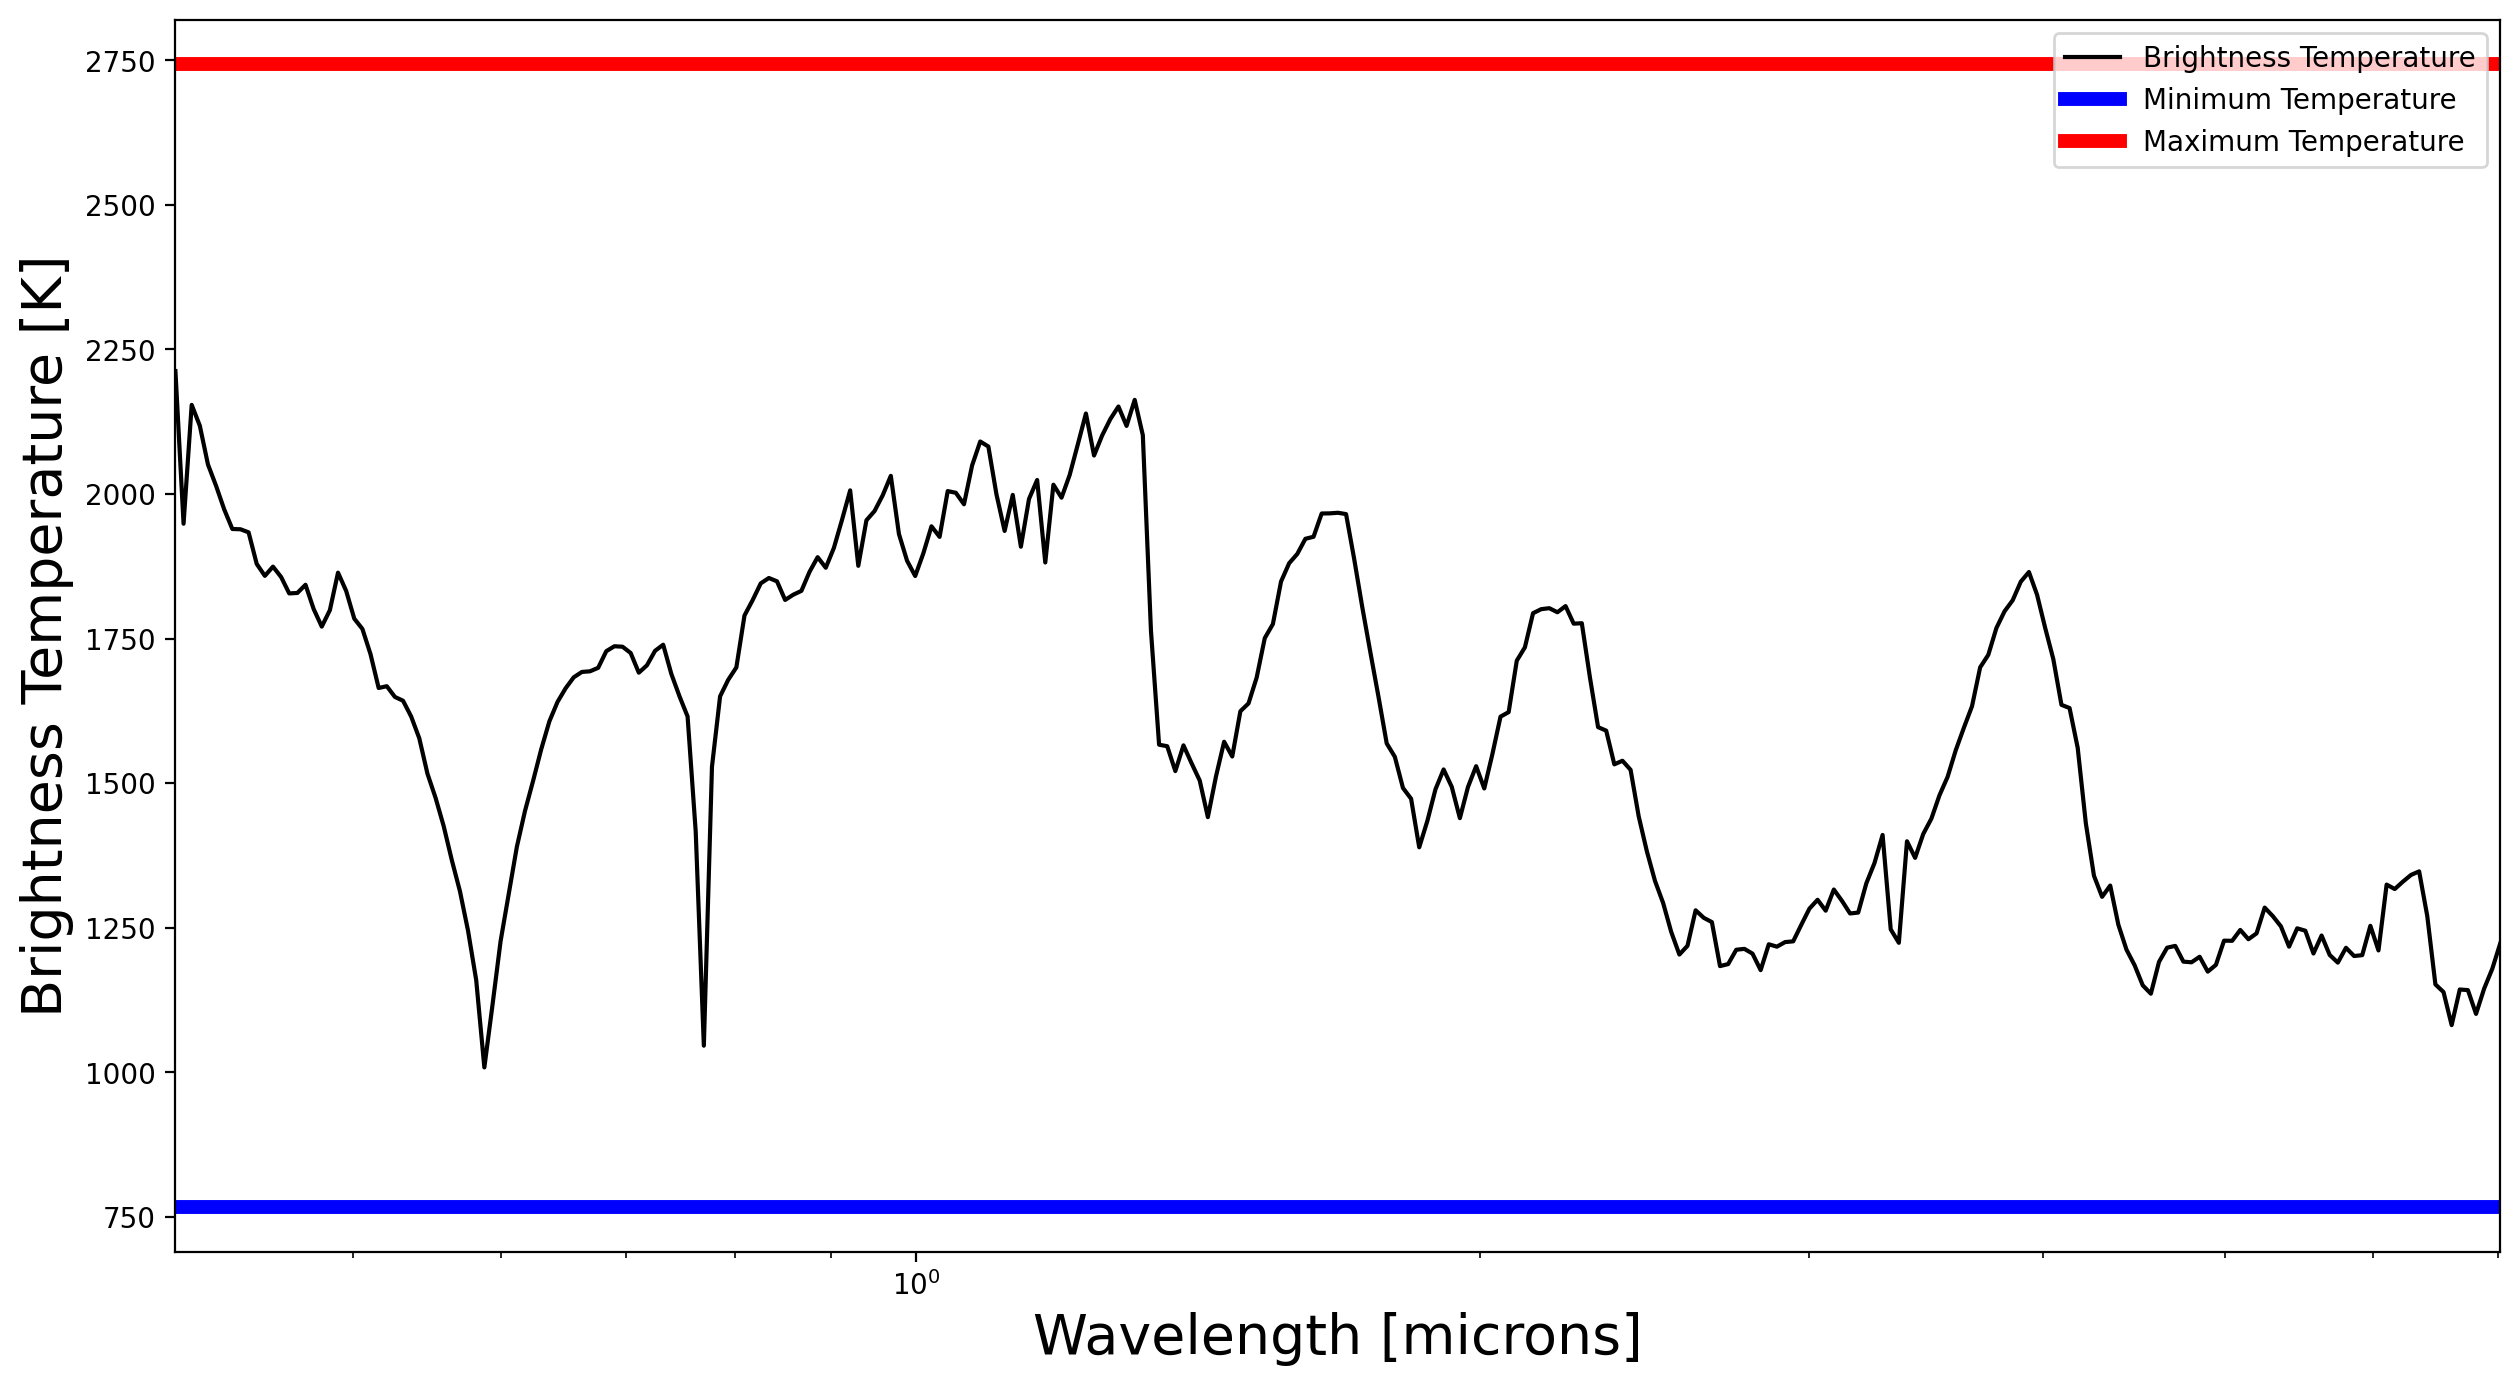

In [42]:
brightness_temp, figure= jpi.brightness_temperature(sonora_spec,R=100)

Note that the plot also delineates the minimum and maximum temperatures of the pressure-temperature profile that was input. This gives you a sense for how your brightness temperature compares to the upper and lower bounds. **A brightness temperature that exceeds the maximum temperature or butts up against the lowest temperature could indicate that your pressure grid does not go to high or low enough pressures.**


In [43]:
# --- EXPLORATION 6 --------------------------------
#Look at results for Sonora-Bobcat models with a range of internal temperatures
#and surface gravities. What pressure levels is flux emerging from?
#Does it depend more on temperature or surface gravity or both equally?
#
#What happens when you add clouds?
# ---------------------------------------------------



> Surface gravity has a larger effect on photospheric pressure than temperature absent a sharp change in chemical abundances. Clouds tend to really restrict the range of pressures that spectra probe!

[notebook top](#top)  |  [section top](#8Interpreting)

-----------
## <a id="9Non-zero"></a> 9. Non-zero Phase Angles

Up to now we have been doing reflected light calculations for full phase only. At that phase we only need to integrate along a single radial direction out from the center of the planet towards the limb, then we can leverage symmetry to get the albedo of the full disk. PICASO was taking care of this under the hood, using a default number of angular integration points.

Once we want to calculate the albedo for a non-zero phase angle, we have to integrate over two angular directions. PICASO uses **gaussian quadrature** to maximize accuracy while minimizing time for the angular integration. Once you are trying to compute for a non-zero phase angle, the you must specify how many gauss quadrature points you want in the latitude and longitude direction with keyword arguments `num_tangle` and `num_gangle`. 

Higher numbers of gauss points will increase precision, but also make your calculation slower. We adopt 10 points in each direction which can be done in reasonable time and with just a few percent error on the resulting albedo spectrum. 


Here is how this would look for our Jupiter-like base case.


In [44]:
#for now we are starting with 10 gauss points in each direction which is a balance of
#speed and precision, this gives a few percent error
cloudy_inputs.phase_angle(np.pi/2.0,     # let's do quadrature phase, alpha = 90 degrees
                          num_tangle=10, # points for integration in the latitude direction
                          num_gangle=10) # points for integration in the longitude direction


Since thermal emission does not have any phase dependence in a uniform 1D atmosphere, PICASO has you calculate thermal emission and reflected-light components separately rather than using the calculation='reflected+thermal' kwarg for non-zero phase angles. Thermal emission with phase angle = 0 can just be added to reflected-light with varying phase angles. 

If you want to consider non-uniform thermal emission, PICASO handles this with `inputs_3d`.

We'll just focus on reflected-light here.

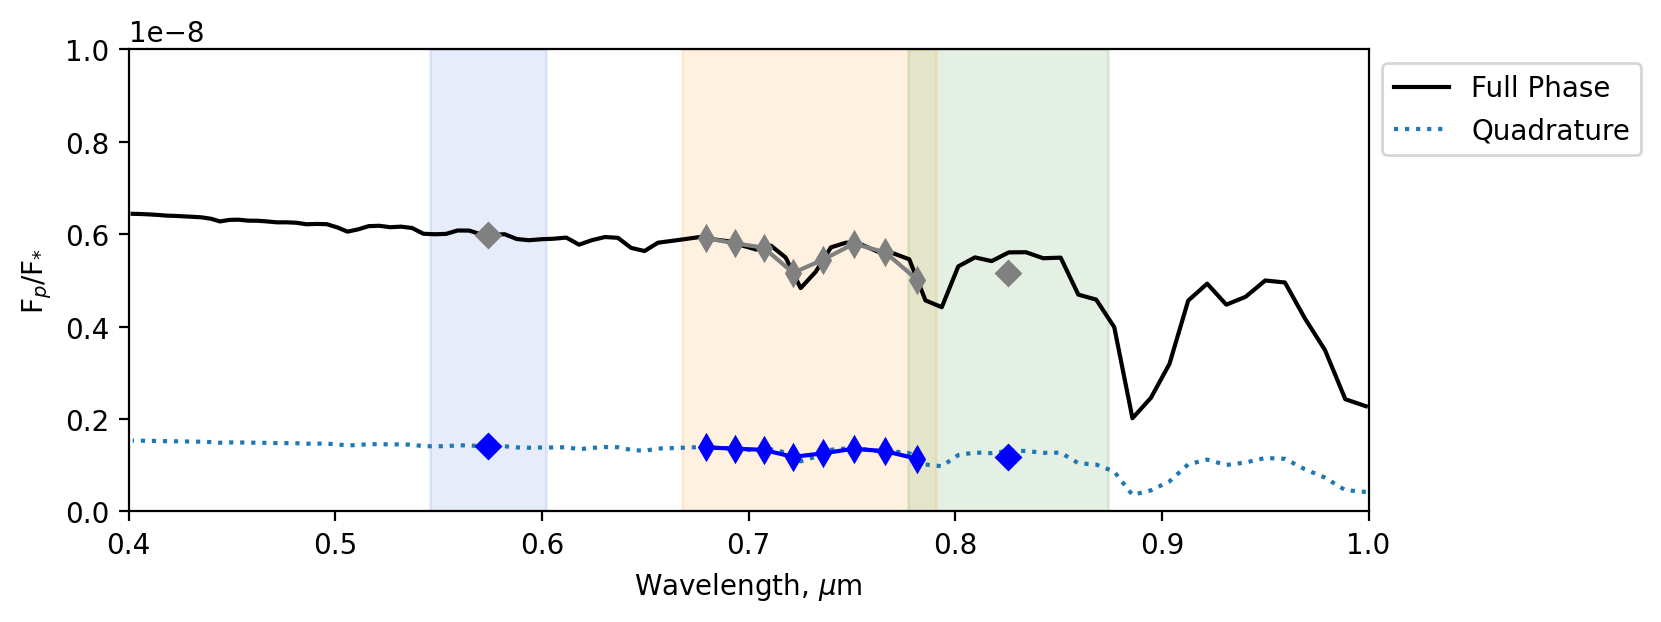

In [45]:
spec_q = cloudy_inputs.spectrum(opa,
                                calculation='reflected') # note we use just 'reflected' this time
wno, fpfs_q = jdi.mean_regrid(spec_q['wavenumber'], 
                              spec_q['fpfs_reflected'] , 
                              R=100) 

#compare quadrature spectrum to full phase
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,1,1)
ax.plot(1e4/wno, fpfs_cloudy, linewidth=1.5, color='k',label='Full Phase')
ax.plot(1e4/wno, fpfs_q,label='Quadrature',linestyle=':')
rtu.plot_roman_cgi_obs(ax,spec_cloudy,color='gray')
rtu.plot_roman_cgi_obs(ax,spec_q,color='blue',spec_key='fpfs_reflected')
rtu.format_roman_cgi_spectrum(ax,0.0,1e-8)
ax.legend(loc='upper left',bbox_to_anchor=(1,1))

> That is much dimmer! 

### Compare PICASO phase-dependent spectra to the Lambertian approximation

Since carefully computing the reflected light can be slow, it is common to approximate the phase-dependent appearance as simply the geometric albedo times a Lambertian phase function: $A_g(\lambda) \times \Phi_{L}(\alpha)$. A Lambertian is an analytic expression that describes the phase function for a uniformly scattering sphere:

$\Phi_{L}(\alpha) = \frac{\textrm{sin}(\alpha)+(\pi-\alpha)\textrm{cos}(\alpha)}{\pi}$

Let's take a look at how this approximation compares to more realistic scattering in Roman-CGI observations.

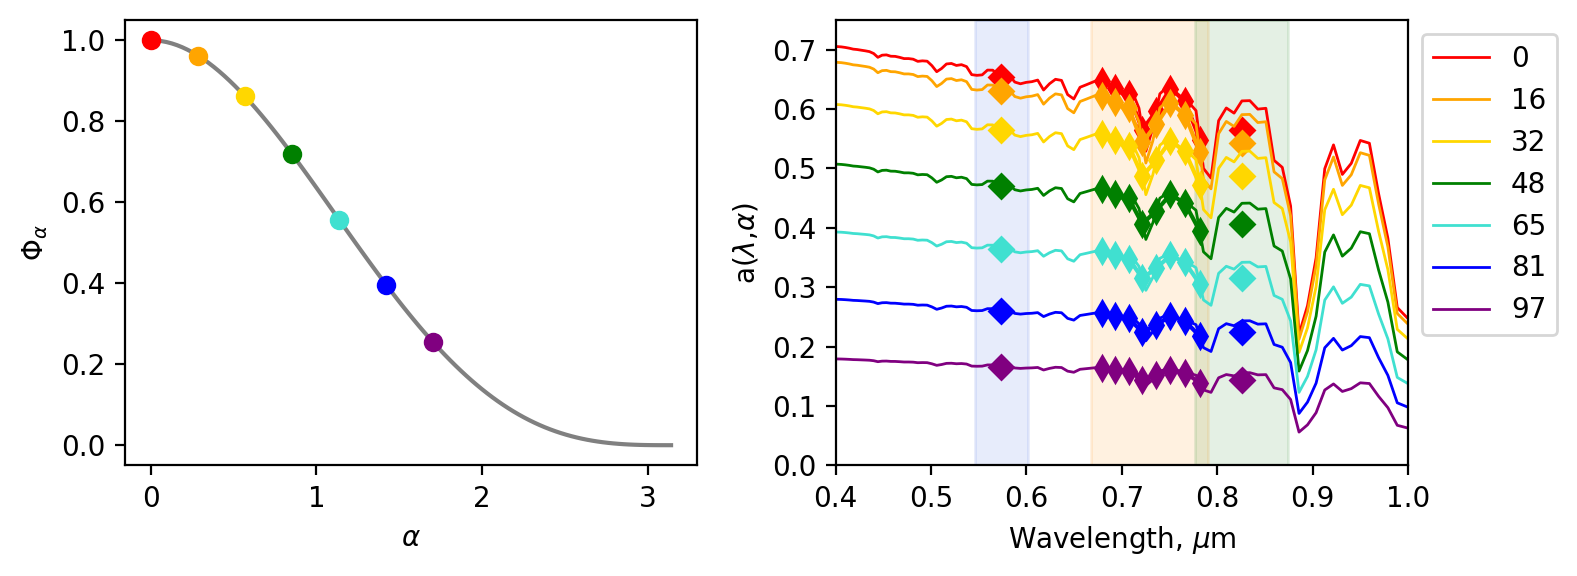

In [46]:
def phi_lambertian(alpha):
    """
    parameters
    ------------
        alpha: orbital phase angle in units of radians
        
    returns
    ------------
        Phi(alpha) following eq 33 in https://iopscience.iop.org/article/10.1088/0004-637X/747/1/25/pdf
    """
    return (np.sin(alpha) + (np.pi - alpha)*np.cos(alpha))/np.pi

# define an array of alpha values
alpha_array = np.linspace(0.0, np.pi*0.995, 12) 

# Ag is defined as the albedo spectrum at alpha=0.0
model_inputs.phase_angle(0.0)
wno, Ag = jdi.mean_regrid(spec_cloudy['wavenumber'], spec_cloudy['albedo'] , R=100)
Ag_b1, Ag_b3, Ag_b4 = rtu.mimic_roman_cgi_obs(spec_cloudy,spec_key='albedo')

# Plot the albedo spectrum assuming a Lambertian phase function
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,2,2)
for alpha,color in zip(alpha_array[:7],['red','orange','gold',
                                        'green','turquoise',
                                        'blue','purple']):
    ax.plot(10**4/wno, Ag*phi_lambertian(alpha),
            linewidth=1,color=color,label="%i"%(alpha*180.0/np.pi))
    ax.plot(Ag_b1[0], Ag_b1[1]*phi_lambertian(alpha),color=color,marker='D')
    ax.plot(Ag_b4[0], Ag_b4[1]*phi_lambertian(alpha),color=color,marker='D')
    ax.plot(Ag_b3[0], Ag_b3[1]*phi_lambertian(alpha),color=color,marker='d')
ax.set_xlabel('Wavelength, $\\mu$m')
ax.set_xlim(0.4,1.0)
ax.legend(loc='upper left',bbox_to_anchor=(1,1))
rtu.format_roman_cgi_spectrum(ax,0.0,0.75,ylabel='a($\\lambda$,$\\alpha$)')

ax = plt.subplot(1,2,1)
alpha_array_cont = np.linspace(0.0, np.pi, 100)
ax.plot(alpha_array_cont,phi_lambertian(alpha_array_cont),color='gray')
for alpha,color in zip(alpha_array,['red','orange','gold',
                                    'green','turquoise',
                                    'blue','purple']):
    ax.plot(alpha, phi_lambertian(alpha),
            linewidth=2,color=color,marker='o')
ax.set_xlabel('$\\alpha$')
ax.set_ylabel('$\\Phi_{\\alpha}$')
plt.tight_layout()

> According to the Lambertian approximation, a cloudy planet being observed in band 1 between quadrature and full phase will have an albedo within the range of 0.2-0.65.

In [47]:
phase_dep_cgi = np.zeros((len(alpha_array),len(Ag_b3[0])+2)) #for storing calcs of Roman-CGI obs at different phase angles
phase_dep_a = np.zeros((len(alpha_array),len(Ag)))  #for the whole albedo spectrum with R~150
phase_dep_cgi[0,0] = Ag_b1[1]
phase_dep_cgi[0,1:-1] = Ag_b3[1]
phase_dep_cgi[0,-1] = Ag_b4[1]
phase_dep_a[0,:] = Ag

print('warning: this loop may take ~3 minutes to run')
for i in range(len(alpha_array)-1):
    alpha = alpha_array[i+1]
    print(i+1,' out of ', len(alpha_array)-1, ' alpha=', alpha)
    cloudy_inputs.phase_angle(alpha,num_tangle=10,num_gangle=10)
    spec_1 = cloudy_inputs.spectrum(opa, calculation='reflected')
    b1,b3,b4 = rtu.mimic_roman_cgi_obs(spec_1,spec_key='albedo')
    phase_dep_cgi[i+1,0] = b1[1]
    phase_dep_cgi[i+1,1:-1] = b3[1]
    phase_dep_cgi[i+1,-1] = b4[1]
    wno, aspec = jdi.mean_regrid(spec_1['wavenumber'], spec_1['albedo'] , R=100)
    phase_dep_a[i+1,:] = aspec

1  out of  11  alpha= 0.284171335483804
2  out of  11  alpha= 0.568342670967608
3  out of  11  alpha= 0.8525140064514121
4  out of  11  alpha= 1.136685341935216
5  out of  11  alpha= 1.42085667741902
6  out of  11  alpha= 1.7050280129028241
7  out of  11  alpha= 1.9891993483866282
8  out of  11  alpha= 2.273370683870432
9  out of  11  alpha= 2.557542019354236
10  out of  11  alpha= 2.84171335483804
11  out of  11  alpha= 3.1258846903218442


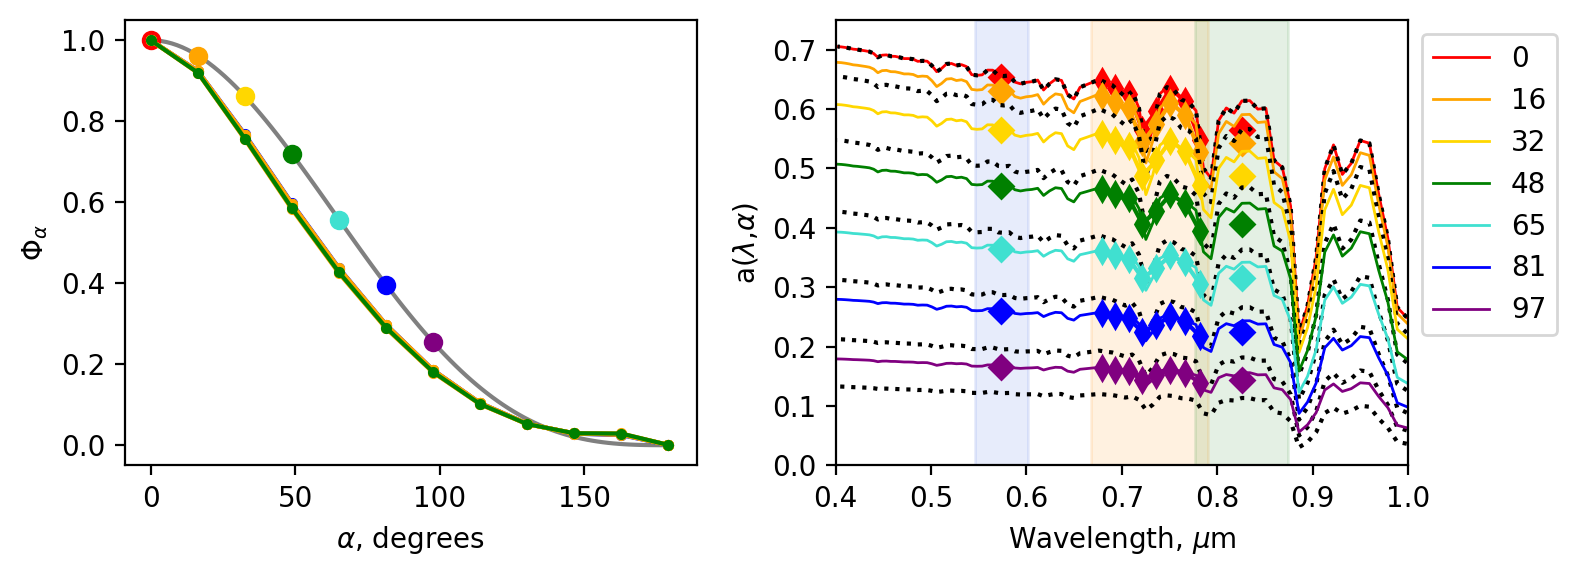

In [48]:
fig = plt.figure(figsize=(8,3))
ax = plt.subplot(1,2,2)
for alpha,color,i in zip(alpha_array,['red','orange','gold',
                                      'green','turquoise',
                                      'blue','purple'],range(7)):
    ax.plot(10**4/wno, Ag*phi_lambertian(alpha),
            linewidth=1,color=color,label="%i"%(alpha*180.0/np.pi))
    ax.plot(Ag_b1[0], Ag_b1[1]*phi_lambertian(alpha),color=color,marker='D')
    ax.plot(Ag_b4[0], Ag_b4[1]*phi_lambertian(alpha),color=color,marker='D')
    ax.plot(Ag_b3[0], Ag_b3[1]*phi_lambertian(alpha),color=color,marker='d')
    ax.plot(10**4/wno,phase_dep_a[i,:],color='k',linestyle=':')
ax.set_xlabel('Wavelength, $\\mu$m')
ax.set_ylabel('a($\\lambda$,$\\alpha$)')
ax.set_xlim(0.4,1.0)
ax.legend(loc='upper left',bbox_to_anchor=(1,1))
rtu.format_roman_cgi_spectrum(ax,0.0,0.75)
ax.set_ylabel('a($\\lambda$,$\\alpha$)')

ax = plt.subplot(1,2,1)
alpha_array_cont = np.linspace(0.0, np.pi, 100)
ax.plot(alpha_array_cont*(180/np.pi),phi_lambertian(alpha_array_cont),color='gray')
for alpha,color in zip(alpha_array,['red','orange','gold',
                                    'green','turquoise',
                                    'blue','purple']):
    ax.plot(alpha*(180/np.pi), phi_lambertian(alpha),
            linewidth=2,color=color,marker='o')
ax.plot(alpha_array*(180/np.pi),phase_dep_cgi[:,0]/phase_dep_cgi[0,0],marker='.',color='blue')
for i in range(1,len(phase_dep_cgi[0,:])-1,1):
    ax.plot(alpha_array*(180/np.pi),phase_dep_cgi[:,i]/phase_dep_cgi[0,i],marker='.',color='orange')
ax.plot(alpha_array*(180/np.pi),phase_dep_cgi[:,-1]/phase_dep_cgi[0,-1],marker='.',color='green')
ax.set_xlabel('$\\alpha$, degrees')
ax.set_ylabel('$\\Phi_{\\alpha}$')
plt.tight_layout()

> The Lambertian approximation is overly optimistic by about 0.1 at most phases between full and quadrature, the phases we are most likely to observe. Right near new moon, the realistic scattering is brighter than the Lambertian approximation. There is not a lot of wavelength dependence to the real phase function across Roman-CGI bandpasses for this Jupiter-like base case. 

> While a Lambertian approximation is not perfect, it is often still used for order of magnitude purposes. You saw how much faster it is to compute the full phase albedo spectrum compared to non-zero phase!  Whether or not it is appropriate will depend on what level of precision your application needs.

In [49]:
# --- EXPLORATION 8 -------------------------------------
#Investigate whether/how the phase-dependence of the albedo spectrum
#changes for the clear case or for other versions of clouds 
#
#Did you find any scenarios where observations at multiple phase angles 
#could help distinguish between atmospheric properties? 
# -------------------------------------------------------



I'm not actually sure about this one, need to do the exploration myself!

[notebook top](#top)  |  [section top](#9Non-zero)

-------------
## <a id="10Culminating"></a> 10. Culminating Parameter-Space Study: 

Using what you have learned, explore how reflected light and thermal emission contribute to flux in Roman-CGI bandpasses across the parameter space of planets' internal temperatures and planet-star separations. You could investigate one or several of the following questions, or define your own!

- Determine where in parameter space thermal emission vs reflected light tends to dominate Roman-CGI bandpasses. You could consider different temperatures, planet-star separations, cloudiness, orbital phase angles, stellar properties etc.
- Determine where in parameter space planet-star flux ratios are above the Roman-CGI best-estimate contrast limit of 10^-9
- For actual Roman-CGI targets, which of these regimes do they fall in? What physical information do we expect encoded in their Roman-CGI observations? Do they look like they are definitely observable by Roman-CGI or is there some ambiguity? The table of target properties from the introductory notebook may be helpful for this.

Feel free to just tackle a subset of this task that most interests you!

In [48]:
#Your Code here!




[notebook top](#top)  |  [section top](#10Culminating)

---------------------
Great Job! Up next, it's time to start connecting models and theory to observations. Proceed to C_comparing_to_observations.ipynb